In [4]:
library(tidyr)
library(readxl)
library(openxlsx)
library(ggrepel)
library(limma)
library(cowplot)
library(tools)
library(snowfall)
library(UpSetR)
library(ComplexHeatmap)
library(tidyverse)
library(furrr)
library(OmnipathR)
library(ggrepel)
library(ggnewscale)
library(ggNetView)

Loading required package: ggplot2

Loading required package: snow

Loading required package: grid

ComplexHeatmap version 2.26.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.4     ✔ tibble    3.3.0
✔ 

# DEG list

In [153]:
deg_list = read.csv("/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4_edgeR_spline_deg.csv",row.names = 1)

# protein secretion

In [285]:
localizations = read.csv("/home/liyanguo/software/OmniPath_localizations.csv",row.names = 1) %>% 
    filter(location=='Secreted')

# L3

## 获取显著性的受配体对

In [95]:
path = "/home/liyanguo/MyImmuCell/12_FastCCC/results_16_CS_L3"

In [96]:
files <- list.files(
  path = path,
  pattern = "_significant_results.tsv",
  recursive = TRUE,
  full.names = TRUE
)

In [97]:
dat <- map_dfr(files, function(i) {
    data <- read.table(i, sep = "\t", header = TRUE, check.names = FALSE)
    data$group <- limma::strsplit2(i, "/")[7]
    return(data)
  })
write.csv(dat,paste0(path,"/significant_results_merge_L3.csv"))

In [98]:
# 筛选分泌型配体 + 生成唯一ID
dat <- dat %>%
    filter(ligand %in% localizations$genesymbol) %>%
    mutate(
      id = paste0(sender_celltype, "|", receiver_celltype, "|", LRI_ID)
    )

## 获取average_interactions_strength.tsv

In [100]:
files <- list.files(
  path = path,
  pattern = "average_interactions_strength.tsv",
  recursive = TRUE,
  full.names = TRUE
)

In [101]:
dat2 <- map_dfr(files, function(i) {
    age_group <- limma::strsplit2(i, "/")[7]
    target_ids <- dat$id[dat$group == age_group]
    
    data <- read.table(i, sep = "\t", header = TRUE, check.names = FALSE)
    colnames(data)[1] <- "celltype"
    
    longer_data <- data %>%
      pivot_longer(
        cols = starts_with("CPI"),
        names_to = "LRI_ID",
        values_to = "average_interactions_strength",
        values_drop_na = TRUE
      ) %>%
      mutate(
        group = age_group,
        id = str_c(celltype, LRI_ID, sep = "|")
      ) %>%
      filter(id %in% target_ids)
    
    return(longer_data)
  })

In [102]:
merge_data <- merge(
    dat, 
    dat2, 
    by = c("id", "group"),  # 同年龄段、同id 匹配
    all.x = TRUE,
    suffixes = c("_sig", "_strength")  # 区分同名列（如LRI_ID）
  ) %>% select(c(sender_celltype,receiver_celltype,LRI_ID_sig,ligand,receptor,`p-value`,average_interactions_strength,group))

In [103]:
table(dat$group)


10-19   2-9 20-29 30-39 40-49 50-59 60-69 70-79 80-89   90+ 
 1302  1170  1443  1397  1434  1392  1325  1310  1352  1325 

In [104]:
table(merge_data$group)


10-19   2-9 20-29 30-39 40-49 50-59 60-69 70-79 80-89   90+ 
 1302  1170  1443  1397  1434  1392  1325  1310  1352  1325 

In [105]:
merge_data

sender_celltype,receiver_celltype,LRI_ID_sig,ligand,receptor,p-value,average_interactions_strength,group
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
ASDC,ASDC,CPI-SS01503DD69,CD44,TYROBP,9.038770e-12,2.2300725,10-19
ASDC,ASDC,CPI-SS01503DD69,CD44,TYROBP,1.491636e-09,2.1380778,20-29
ASDC,ASDC,CPI-SS01503DD69,CD44,TYROBP,8.019990e-11,2.2189519,50-59
ASDC,ASDC,CPI-SS01503DD69,CD44,TYROBP,1.115774e-14,2.2569768,60-69
ASDC,ASDC,CPI-SS01503DD69,CD44,TYROBP,1.276756e-15,2.2730093,70-79
ASDC,ASDC,CPI-SS01503DD69,CD44,TYROBP,1.221245e-15,2.2412162,80-89
ASDC,ASDC,CPI-SS0AE964947,GAS6,AXL,0.000000e+00,1.6261306,10-19
ASDC,ASDC,CPI-SS0AE964947,GAS6,AXL,0.000000e+00,1.5712274,2-9
ASDC,ASDC,CPI-SS0AE964947,GAS6,AXL,0.000000e+00,1.4687007,20-29


In [106]:
write.csv(merge_data,paste0(path,"merge_average_interactions_strength_L3.csv"))

# L4

## 获取显著性的受配体对

In [107]:
path = "/home/liyanguo/MyImmuCell/12_FastCCC/results_16_CS_L4"

In [108]:
files <- list.files(
  path = path,
  pattern = "_significant_results.tsv",
  recursive = TRUE,
  full.names = TRUE
)

In [109]:
dat <- map_dfr(files, function(i) {
    data <- read.table(i, sep = "\t", header = TRUE, check.names = FALSE)
    data$group <- limma::strsplit2(i, "/")[7]
    return(data)
  })
write.csv(dat,paste0(path,"/significant_results_merge_L4.csv"))

In [110]:
# 筛选分泌型配体 + 生成唯一ID
dat <- dat %>%
    filter(ligand %in% localizations$genesymbol) %>%
    mutate(
      id = paste0(sender_celltype, "|", receiver_celltype, "|", LRI_ID)
    )

## 获取average_interactions_strength.tsv

In [111]:
files <- list.files(
  path = path,
  pattern = "average_interactions_strength.tsv",
  recursive = TRUE,
  full.names = TRUE
)

In [112]:
dat2 <- map_dfr(files, function(i) {
    age_group <- limma::strsplit2(i, "/")[7]
    target_ids <- dat$id[dat$group == age_group]
    
    data <- read.table(i, sep = "\t", header = TRUE, check.names = FALSE)
    colnames(data)[1] <- "celltype"
    
    longer_data <- data %>%
      pivot_longer(
        cols = starts_with("CPI"),
        names_to = "LRI_ID",
        values_to = "average_interactions_strength",
        values_drop_na = TRUE
      ) %>%
      mutate(
        group = age_group,
        id = str_c(celltype, LRI_ID, sep = "|")
      ) %>%
      filter(id %in% target_ids)
    
    return(longer_data)
  })

In [113]:
merge_data <- merge(
    dat, 
    dat2, 
    by = c("id", "group"),  # 同年龄段、同id 匹配
    all.x = TRUE,
    suffixes = c("_sig", "_strength")  # 区分同名列（如LRI_ID）
  ) %>% select(c(id,sender_celltype,receiver_celltype,LRI_ID_sig,ligand,receptor,`p-value`,average_interactions_strength,group))

In [114]:
table(dat$group)


10-19   2-9 20-29 30-39 40-49 50-59 60-69 70-79 80-89   90+ 
 6686  6644  7897  7845  7900  7599  7307  7213  7343  7290 

In [115]:
table(merge_data$group)


10-19   2-9 20-29 30-39 40-49 50-59 60-69 70-79 80-89   90+ 
 6686  6644  7897  7845  7900  7599  7307  7213  7343  7290 

In [116]:
merge_data

id,sender_celltype,receiver_celltype,LRI_ID_sig,ligand,receptor,p-value,average_interactions_strength,group
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
Adaptive NK cells|Adaptive NK cells|CPI-SC0DABCC4B5,Adaptive NK cells,Adaptive NK cells,CPI-SC0DABCC4B5,TGFB1,"TGFBR1,TGFBR2",2.220446e-16,1.251718,20-29
Adaptive NK cells|Adaptive NK cells|CPI-SC0DABCC4B5,Adaptive NK cells,Adaptive NK cells,CPI-SC0DABCC4B5,TGFB1,"TGFBR1,TGFBR2",5.551115e-17,1.229890,30-39
Adaptive NK cells|Adaptive NK cells|CPI-SC0DABCC4B5,Adaptive NK cells,Adaptive NK cells,CPI-SC0DABCC4B5,TGFB1,"TGFBR1,TGFBR2",1.665335e-16,1.237191,40-49
Adaptive NK cells|Adaptive NK cells|CPI-SC0DABCC4B5,Adaptive NK cells,Adaptive NK cells,CPI-SC0DABCC4B5,TGFB1,"TGFBR1,TGFBR2",5.551115e-17,1.216695,50-59
Adaptive NK cells|Adaptive NK cells|CPI-SS056FF4363,Adaptive NK cells,Adaptive NK cells,CPI-SS056FF4363,CD48,CD244,5.551115e-17,1.167183,20-29
Adaptive NK cells|Adaptive NK cells|CPI-SS056FF4363,Adaptive NK cells,Adaptive NK cells,CPI-SS056FF4363,CD48,CD244,0.000000e+00,1.162879,30-39
Adaptive NK cells|Adaptive NK cells|CPI-SS056FF4363,Adaptive NK cells,Adaptive NK cells,CPI-SS056FF4363,CD48,CD244,5.551115e-17,1.159521,40-49
Adaptive NK cells|Adaptive NK cells|CPI-SS056FF4363,Adaptive NK cells,Adaptive NK cells,CPI-SS056FF4363,CD48,CD244,0.000000e+00,1.161389,50-59
Adaptive NK cells|Adaptive NK cells|CPI-SS085EE60B1,Adaptive NK cells,Adaptive NK cells,CPI-SS085EE60B1,TGFB1,TGFBR3,0.000000e+00,1.450174,10-19


In [117]:
write.csv(merge_data,paste0(path,"merge_average_interactions_strength_L4.csv"))

# 所有细胞计算NEU参与比例

In [322]:
merge_data = read.csv('/home/liyanguo/MyImmuCell/12_FastCCC/results_16_CS_L4merge_average_interactions_strength_L4.csv',row.names = 1)

In [323]:
merge_data$id = paste0(merge_data$sender_celltype,'|',merge_data$receiver_celltype,'|',
                       merge_data$LRI_ID_sig)

In [324]:
plot_data2 = merge_data %>% pivot_wider(id_cols = id,
              names_from = group,
              values_from = average_interactions_strength,
              values_fill = NA
             )# %>% select('id','2-9','10-19','20-29','30-39','40-49','50-59','60-69','70-79','80-89','90+') %>% column_to_rownames(var='id')

In [326]:
plot_data2$label = ifelse(grepl('DNs',plot_data2$id), ifelse(grepl('LDNs',plot_data2$id),'LDNs','NDNs'),"Niches")

In [327]:
plot_data2

id,20-29,30-39,40-49,50-59,10-19,2-9,60-69,70-79,80-89,90+,label
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Adaptive NK cells|Adaptive NK cells|CPI-SC0DABCC4B5,1.251718,1.229890,1.2371909,1.216695,NA,NA,NA,NA,NA,NA,Niches
Adaptive NK cells|Adaptive NK cells|CPI-SS056FF4363,1.167183,1.162879,1.1595206,1.161389,NA,NA,NA,NA,NA,NA,Niches
Adaptive NK cells|Adaptive NK cells|CPI-SS085EE60B1,1.357152,1.369980,1.3761490,1.404197,1.450174,1.430755,1.410513,1.419322,1.439185,1.407269,Niches
Adaptive NK cells|Adaptive NK cells|CPI-SS0E2453044,1.630882,1.631999,1.6439612,1.643804,1.585117,1.588332,1.624103,1.618194,1.620814,1.638685,Niches
Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS01503DD69,NA,1.799034,NA,NA,NA,1.813339,NA,NA,NA,NA,NDNs
Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS030BB46BB,1.460198,1.471917,1.4829446,1.485353,NA,NA,NA,NA,NA,NA,NDNs
Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS0F739D3DB,2.617674,2.634965,2.6559736,2.661522,2.551681,2.536058,2.710212,2.696527,2.684764,2.704386,NDNs
Adaptive NK cells|ASDC|CPI-SC0DABCC4B5,NA,NA,NA,NA,1.288453,NA,NA,1.154580,1.078440,1.056044,Niches
Adaptive NK cells|ASDC|CPI-SS0B01D306C,NA,NA,1.5439537,NA,NA,NA,NA,NA,NA,NA,Niches


In [329]:
plot_data = as.data.frame(table(plot_data2$label))
plot_data

Var1,Freq
<fct>,<int>
LDNs,398
NDNs,2131
Niches,7216


In [330]:
label_ = paste0(round(plot_data$Freq/(sum(plot_data$Freq))*100,2),'%')
p=ggplot(plot_data, aes(x = 1, y = Freq, fill = Var1)) +
  geom_col(width = 0.3, color = "white") +                  
  coord_polar(theta = "y", start = 0) +                     
  geom_text(aes(label = label_), 
            position = position_stack(vjust = 0.5), 
            size = 3) +
scale_fill_brewer(palette = "Set3") +
  theme_void() +
  labs(fill = "Cell type") +
  xlim(0.5, 1.5)   # 调整 x 轴范围，产生空心效果

ggsave2("/home/liyanguo/MyImmuCell/12_FastCCC/L4_CCC_perrcent.pdf",p,width = 5,height = 5)

# 所有细胞分别计算作为信号发送和接受者的总通讯强度

In [217]:
merge_data = read.csv('/home/liyanguo/MyImmuCell/12_FastCCC/results_16_CS_L4merge_average_interactions_strength_L4.csv',row.names = 1)

In [192]:
outgoing <- merge_data %>%
  group_by(sender_celltype) %>%
  summarise(outgoing_strength = sum(average_interactions_strength),
           outgoing_num = n())

In [193]:
incoming <- merge_data %>%
  group_by(receiver_celltype) %>%
  summarise(incoming_strength = sum(average_interactions_strength),
           incoming_num = n())

In [194]:
cell_comm <- full_join(outgoing, incoming,
                       by = c("sender_celltype" = "receiver_celltype"))

In [195]:
cell_comm <- cell_comm %>%
    mutate(label = if_else(grepl("DNs", sender_celltype) | grepl("monocyte", sender_celltype) | grepl("Platelets", sender_celltype), sender_celltype, NA))

In [205]:
p = ggplot(cell_comm, aes(x = incoming_num, y = outgoing_num)) +
  geom_point(aes(size = incoming_num, color = incoming_strength), alpha = 0.6,shape=16) +
  geom_text_repel(
    aes(label = label),
    na.rm = TRUE,
    size = 3,
    box.padding = 1,
    point.padding = 0.3,
    segment.color = "grey50",
    segment.size = 0.3,
    max.overlaps = Inf,
      min.segment.length = 1,force_pull = 0.5
  ) +
  scale_size_continuous(range = c(2, 8), name = "Incoming number") +
  scale_color_viridis_c(option = "plasma", name = "Incoming strength") +
  labs(x = "Incoming number", y = "Outgoing number",
       title = "Cell communication strength") +
  theme_classic(base_size = 12) +
  theme(legend.position = "right",
        plot.title = element_text(hjust = 0.5),
        panel.grid.minor = element_blank())
ggsave2("/home/liyanguo/MyImmuCell/12_FastCCC/L4_CCC_overview.pdf",p,width = 10,height = 8)

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


# Top受配体可视化

## top LR NEU as sender

In [236]:
merge_data = read.csv('/home/liyanguo/MyImmuCell/12_FastCCC/results_16_CS_L4merge_average_interactions_strength_L4.csv',row.names = 1)

In [237]:
merge_data_NEU = merge_data[grepl('NDNs',merge_data$sender_celltype) | grepl('LDNs',merge_data$sender_celltype),]

In [238]:
merge_data_NEU <- merge_data_NEU %>% 
  mutate(LR = paste(ligand, receptor, sep = "_"))

In [243]:
lr_count <- merge_data_NEU %>%
  group_by(group, LR) %>%
  summarise(n = n(), .groups = "drop")

In [249]:
lr_count

group,LR,n,LR_group
<chr>,<chr>,<int>,<chr>
10-19,ANXA1_FPR1,28,ANXA1_FPR1
10-19,BAG6_NCR3,3,Other
10-19,CD177_PECAM1,22,CD177_PECAM1
10-19,CD55_ADGRE5,103,CD55_ADGRE5
10-19,CXCL8_CXCR1,72,CXCL8_CXCR1
10-19,CXCL8_CXCR2,72,CXCL8_CXCR2
10-19,PPIA_BSG,7,PPIA_BSG
10-19,RNASET2_TLR8,33,RNASET2_TLR8
10-19,"TGFB1_TGFBR1,TGFBR2",6,Other


In [246]:
top10 <- lr_count %>%
  group_by(LR) %>%
  summarise(total = sum(n)) %>%
  arrange(desc(total)) %>%
  slice(1:10) %>%
  pull(LR)

In [247]:
top10

[1] "TGFB1_TGFBR3"      "CD55_ADGRE5"       "CXCL8_CXCR2"      
 [4] "CXCL8_CXCR1"       "TNFSF10_TNFRSF10C" "TNFSF10_TNFRSF10B"
 [7] "RNASET2_TLR8"      "ANXA1_FPR1"        "CD177_PECAM1"     
[10] "PPIA_BSG"

In [248]:
lr_count <- lr_count %>%
  mutate(LR_group = ifelse(LR %in% top10, LR, "Other"))

In [250]:
plot_df <- lr_count %>%
  group_by(group, LR_group) %>%
  summarise(n = sum(n), .groups = "drop") %>%
  group_by(group) %>%
  mutate(percent = n / sum(n))

In [252]:
plot_df$group = factor(plot_df$group,
                       levels = c('2-9','10-19','20-29','30-39','40-49','50-59','60-69','70-79','80-89','90+'))

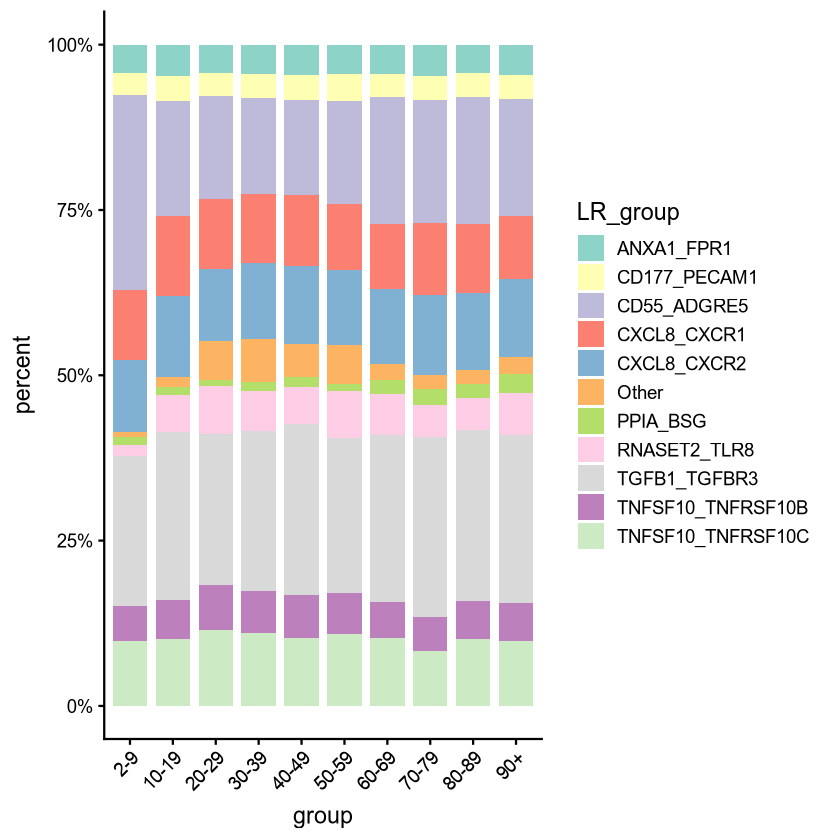

In [253]:
p = ggplot(plot_df, aes(x = group, y = percent, fill = LR_group)) +
  geom_bar(stat = "identity", width = 0.8) +
  scale_y_continuous(labels = scales::percent_format()) +
  scale_fill_brewer(palette = "Set3") +
  theme_classic(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )
p

In [254]:
ggsave2("/home/liyanguo/MyImmuCell/12_FastCCC/top10_LR_NEU_as_sender.pdf",p,width = 6,height = 4)

## top LR NEU as receiver

In [255]:
merge_data = read.csv('/home/liyanguo/MyImmuCell/12_FastCCC/results_16_CS_L4merge_average_interactions_strength_L4.csv',row.names = 1)

In [256]:
merge_data_NEU = merge_data[grepl('NDNs',merge_data$receiver_celltype) | grepl('LDNs',merge_data$receiver_celltype),]

In [257]:
merge_data_NEU <- merge_data_NEU %>% 
  mutate(LR = paste(ligand, receptor, sep = "_"))

In [258]:
lr_count <- merge_data_NEU %>%
  group_by(group, LR) %>%
  summarise(n = n(), .groups = "drop")

In [259]:
top10 <- lr_count %>%
  group_by(LR) %>%
  summarise(total = sum(n)) %>%
  arrange(desc(total)) %>%
  slice(1:10) %>%
  pull(LR)

In [260]:
top10

[1] "CD44_TYROBP"       "ANXA1_FPR1"        "ANXA1_FPR2"       
 [4] "TNFSF10_TNFRSF10C" "CD55_ADGRE5"       "CXCL8_CXCR2"      
 [7] "CXCL8_CXCR1"       "PPIA_BSG"          "LGALS9_P4HB"      
[10] "FCER2_ITGAX,ITGB2"

In [261]:
lr_count <- lr_count %>%
  mutate(LR_group = ifelse(LR %in% top10, LR, "Other"))

In [262]:
plot_df <- lr_count %>%
  group_by(group, LR_group) %>%
  summarise(n = sum(n), .groups = "drop") %>%
  group_by(group) %>%
  mutate(percent = n / sum(n))

In [263]:
plot_df$group = factor(plot_df$group,
                       levels = c('2-9','10-19','20-29','30-39','40-49','50-59','60-69','70-79','80-89','90+'))

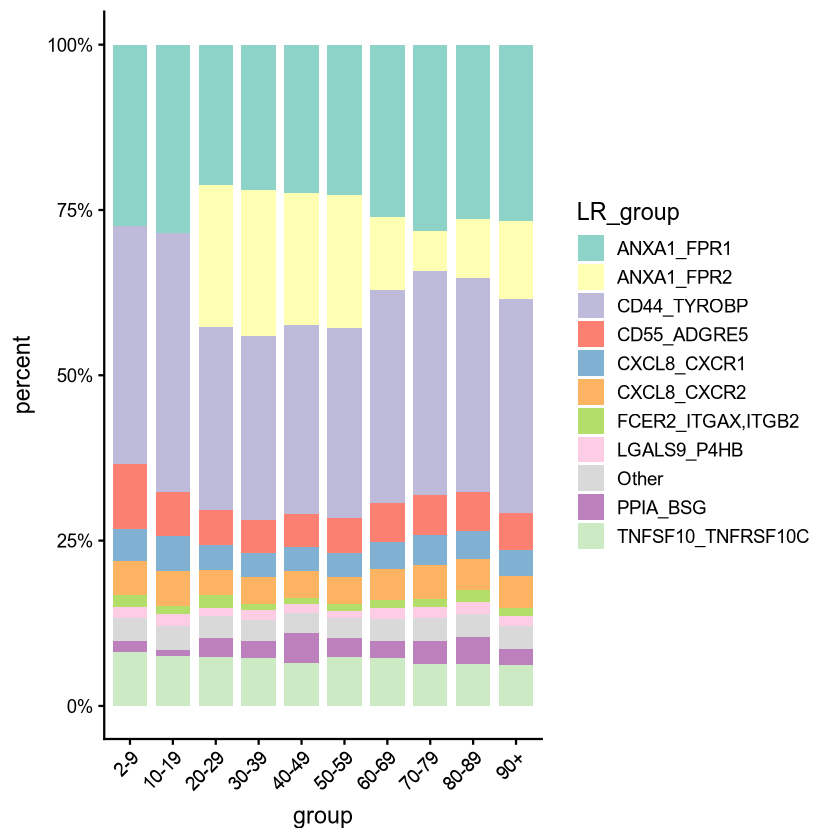

In [264]:
p = ggplot(plot_df, aes(x = group, y = percent, fill = LR_group)) +
  geom_bar(stat = "identity", width = 0.8) +
  scale_y_continuous(labels = scales::percent_format()) +
  scale_fill_brewer(palette = "Set3") +
  theme_classic(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )
p

In [265]:
ggsave2("/home/liyanguo/MyImmuCell/12_FastCCC/top10_LR_NEU receive.pdf",plot = p,width = 6,height = 4)

# 弦图显示其他细胞和NDN之间的分泌型受配体关系

In [314]:
merge_data = read.csv('/home/liyanguo/MyImmuCell/12_FastCCC/results_16_CS_L4merge_average_interactions_strength_L4.csv',row.names = 1,check.names = F)

In [315]:
data2 = as.data.frame(table(merge_data$sender_celltype,merge_data$receiver_celltype))
colnames(data2)=c('sender_celltype','receiver_celltype','Freq')

In [316]:
data3 = data2 %>% pivot_wider(id_cols = sender_celltype,
              names_from = receiver_celltype,
              values_from = Freq,
              values_fill = 0
             )

In [317]:
#做弦图 NEU as sender
data_NEU_sender = data3[grepl('DNs',data3$sender_celltype),] %>% as.data.frame() %>% column_to_rownames(var='sender_celltype')

In [318]:
write.csv(data_NEU_sender,'/home/liyanguo/MyImmuCell/12_FastCCC/NDN_chordal_sender_L4.csv')

In [307]:
merge_data = read.csv('/home/liyanguo/MyImmuCell/12_FastCCC/results_16_CS_L4merge_average_interactions_strength_L4.csv',row.names = 1)

In [308]:
#x=receiver_celltype y=sender_celltype
data2 = as.data.frame(table(merge_data$receiver_celltype,merge_data$sender_celltype))
colnames(data2)=c('receiver_celltype','sender_celltype','Freq')

In [309]:
data3 = data2 %>% pivot_wider(id_cols = receiver_celltype,
              names_from = sender_celltype,
              values_from = Freq,
              values_fill = 0
             )

In [311]:
data_NEU_receiver = data3[grepl('DNs',data3$receiver_celltype),] %>% as.data.frame() %>% column_to_rownames(var='receiver_celltype')

In [313]:
#做弦图 NEU as receiver
write.csv(data_NEU_receiver,'/home/liyanguo/MyImmuCell/12_FastCCC/NDN_chordal_rerceiver_L4.csv.csv')

# NEU为sender，桑基图

In [358]:
merge_data = read.csv('/home/liyanguo/MyImmuCell/12_FastCCC/results_16_CS_L4merge_average_interactions_strength_L4.csv',row.names = 1)

In [359]:
merge_data$id = paste0(merge_data$sender_celltype,'|',merge_data$receiver_celltype,'|',
                       merge_data$LRI_ID_sig)

In [363]:
merge_data$Sender = ifelse(grepl('DNs',merge_data$sender_celltype), ifelse(grepl('LDNs',merge_data$sender_celltype),'LDNs','NDNs'),"Niches")
merge_data$Receiver = ifelse(grepl('DNs',merge_data$receiver_celltype), ifelse(grepl('LDNs',merge_data$receiver_celltype),'LDNs','NDNs'),"Niches")
merge_data$LRI = paste0(merge_data$ligand,'-',merge_data$receptor)

In [368]:
sankey = merge_data %>% select(Sender,Receiver,LRI) %>%  group_by(Sender, Receiver, LRI) %>%  summarise(Freq = n(), .groups = "drop") %>% filter(Sender!='Niches')
sankey

Sender,Receiver,LRI,Freq
<chr>,<chr>,<chr>,<int>
LDNs,LDNs,CD177-PECAM1,2
LDNs,LDNs,CD55-ADGRE5,2
LDNs,NDNs,ANXA1-FPR1,180
LDNs,NDNs,ANXA1-FPR2,92
LDNs,NDNs,CD177-PECAM1,90
LDNs,NDNs,CD55-ADGRE5,22
LDNs,Niches,ANXA1-FPR1,99
LDNs,Niches,BAG6-NCR3,3
LDNs,Niches,CD177-PECAM1,135


In [419]:
library(tidyverse)
library(ggalluvial)

lri_order <- sankey %>%
  group_by(LRI) %>%
  summarise(total = sum(Freq)) %>%
  arrange(desc(total)) %>%
  pull(LRI)

df_alluvial <- sankey %>%
  mutate(
    LRI = factor(LRI, levels = lri_order),
    Sender_plot = paste0(Sender, "_S"),
    Receiver_plot = paste0(Receiver, "_R")
  )

sender_cols <- c("LDNs_S" = "#D0DEAA", "NDNs_S" = "#E16C96")
receiver_cols <- c("LDNs_R" = "#D0DEAA", "NDNs_R" = "#E16C96","Niches_R" = "#0EB0C9")

lri_cols <- setNames(
  colorRampPalette(c("#1E90FF", "#D8BFD8", "#B0C4DE"))(length(lri_order)),
  lri_order
)

all_cols <- c(lri_cols, sender_cols, receiver_cols)

p = ggplot(df_alluvial,
       aes(axis1 = Sender_plot, axis2 = LRI, axis3 = Receiver_plot,
           y = Freq)) +
  
  geom_alluvium(aes(fill = LRI),
                width = 0.25,
                alpha = 0.85) +
  
  geom_stratum(aes(fill = after_stat(stratum)),
               width = 0.25,size = 0.1,
               color = "black") +
  
  geom_text(stat = "stratum",
            aes(label = gsub("_S|_R", "", after_stat(stratum))),
            size = 1) +
  
  scale_fill_manual(values = all_cols) +
  
  scale_x_discrete(limits = c("Sender", "LRI", "Receiver"),
                   labels = c("Sender", "LRI", "Receiver"),
                   expand = c(.08, .08)) +
  
  theme_minimal(base_size = 8) +
  theme(
    axis.title.x = element_blank(),
    axis.text.y = element_blank(),
    panel.grid = element_blank(),
    axis.text.x = element_text(size = 8),
    legend.position = "none"
  )

In [420]:
ggsave2("/home/liyanguo/MyImmuCell/12_FastCCC/NEU_sender_sankey.pdf",plot = p,width = 4,height = 6)

# NEU在不同年龄段通讯数量和强度的分化趋势，异质性

In [445]:
merge_data = read.csv('/home/liyanguo/MyImmuCell/12_FastCCC/results_16_CS_L4merge_average_interactions_strength_L4.csv',row.names = 1)

In [446]:
library(tidyverse)

outgoing <- merge_data %>%
  filter(grepl("DNs", sender_celltype)) %>%
  group_by(sender_celltype, group) %>%
  summarise(
    outgoing_strength = sum(average_interactions_strength),
    outgoing_num = n(),
    .groups = "drop"
  ) %>%
  mutate(
    group = factor(group, levels = c(
      '2-9','10-19','20-29','30-39','40-49',
      '50-59','60-69','70-79','80-89','90+'
    )),
    sender_celltype = factor(sender_celltype, levels = c(
      'Core NDNs',
      'IRF1- GBP2- NDNs',
      'IFIT2- RNF213- NDNs',
      'VIM- FLNA- NDNs',
      'CXCL8- PTGS2+ NDNs',
      'FOS- NDNs',
      'MT-ATP6- MT-CO2- NDNs',
      'ALPL- MARCKS- NDNs',
      'RGS2- NDNs',
      'MMP8+ CD177+ iLDNs',
      'MPO- CD177- iLDNs'
    ))
  )

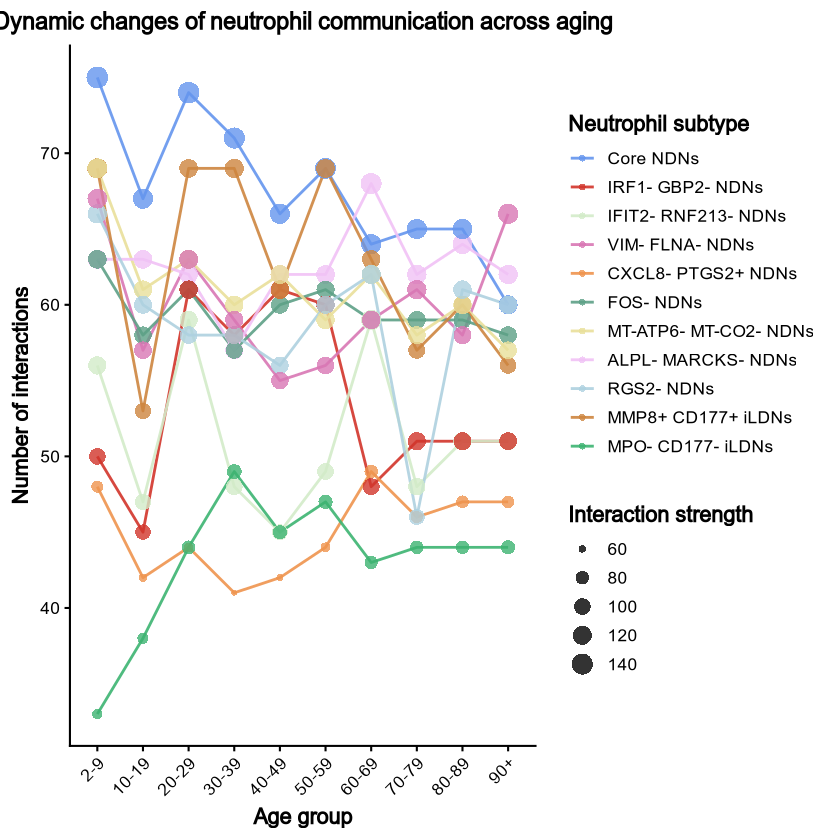

In [447]:
neu_cols <- c(
  '#6495ED','#D1352B','#D2EBC8','#D877B4','#EE934E','#5DA086','#e8df9a','#f0c1f5', '#AED0DF','#CD853F','#3CB371'
)
p <- ggplot(outgoing,
            aes(x = group,
                y = outgoing_num,
                group = sender_celltype,
                color = sender_celltype)) +
  
  geom_line(linewidth = 0.8, alpha = 0.9) +
  
  geom_point(aes(size = outgoing_strength),
             alpha = 0.8,shape=16,
             stroke = 0.2) +
  
  scale_size_continuous(
    range = c(1.5, 6),
    name = "Interaction strength"
  ) +
  
  scale_color_manual(values = neu_cols) +
  
  labs(
    x = "Age group",
    y = "Number of interactions",
    title = "Dynamic changes of neutrophil communication across aging outgoing",
    color = "Neutrophil subtype"
  ) +
  
  theme_classic(base_size = 13) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    
    axis.title = element_text(face = "bold"),
    
    legend.position = "right",
    legend.title = element_text(face = "bold"),
    
    plot.title = element_text(
      hjust = 0.5,
      face = "bold",
      size = 14
    ),
    
    panel.border = element_blank()
  )
p

In [448]:
ggsave2("/home/liyanguo/MyImmuCell/12_FastCCC/NEU_sender_age_group.pdf",plot = p,width = 6,height = 6)

In [449]:
library(tidyverse)

incoming <- merge_data %>%
  filter(grepl("DNs", receiver_celltype)) %>%
  group_by(receiver_celltype, group) %>%
  summarise(
    incoming_strength = sum(average_interactions_strength),
    incoming_num = n(),
    .groups = "drop"
  ) %>%
  mutate(
    group = factor(group, levels = c(
      '2-9','10-19','20-29','30-39','40-49',
      '50-59','60-69','70-79','80-89','90+'
    )),
    receiver_celltype = factor(receiver_celltype, levels = c(
      'Core NDNs',
      'IRF1- GBP2- NDNs',
      'IFIT2- RNF213- NDNs',
      'VIM- FLNA- NDNs',
      'CXCL8- PTGS2+ NDNs',
      'FOS- NDNs',
      'MT-ATP6- MT-CO2- NDNs',
      'ALPL- MARCKS- NDNs',
      'RGS2- NDNs',
      'MMP8+ CD177+ iLDNs',
      'MPO- CD177- iLDNs'
    ))
  )

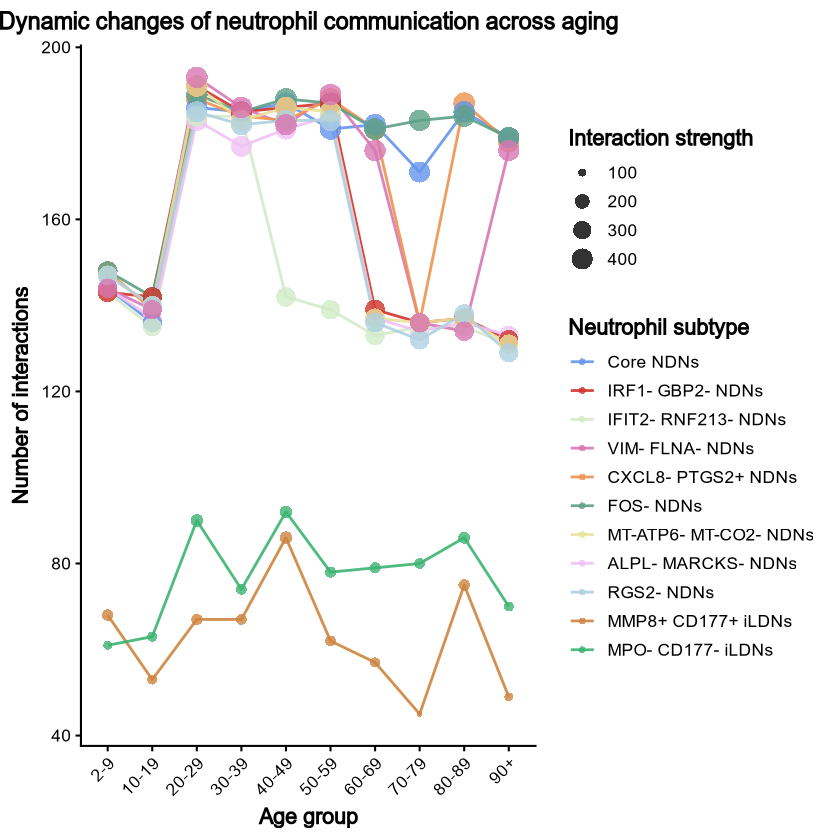

In [450]:
neu_cols <- c(
  '#6495ED','#D1352B','#D2EBC8','#D877B4','#EE934E','#5DA086','#e8df9a','#f0c1f5', '#AED0DF','#CD853F','#3CB371'
)
p <- ggplot(incoming,
            aes(x = group,
                y = incoming_num,
                group = receiver_celltype,
                color = receiver_celltype)) +
  
  geom_line(linewidth = 0.8, alpha = 0.9) +
  
  geom_point(aes(size = incoming_strength),
             alpha = 0.8,shape=16,
             stroke = 0.2) +
  
  scale_size_continuous(
    range = c(1.5, 6),
    name = "Interaction strength"
  ) +
  
  scale_color_manual(values = neu_cols) +
  
  labs(
    x = "Age group",
    y = "Number of interactions",
    title = "Dynamic changes of neutrophil communication across aging incoming",
    color = "Neutrophil subtype"
  ) +
  
  theme_classic(base_size = 13) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    
    axis.title = element_text(face = "bold"),
    
    legend.position = "right",
    legend.title = element_text(face = "bold"),
    
    plot.title = element_text(
      hjust = 0.5,
      face = "bold",
      size = 14
    ),
    
    panel.border = element_blank()
  )
p

In [451]:
ggsave2("/home/liyanguo/MyImmuCell/12_FastCCC/NEU_receiver_age_group.pdf",plot = p,width = 6,height = 6)

# 热图可视化与NEU相关，不同年龄段通讯强度和数量

In [234]:
merge_data = read.csv('/home/liyanguo/MyImmuCell/12_FastCCC/results_16_CS_L4merge_average_interactions_strength_L4.csv',row.names = 1)

In [235]:
merge_data$id = paste0(merge_data$sender_celltype,'|',merge_data$receiver_celltype,'|',
                       merge_data$LRI_ID_sig)

In [236]:
merge_data_NEU = merge_data[grepl('NDNs',merge_data$id) | grepl('LDNs',merge_data$id),]

In [237]:
dim(merge_data_NEU)

[1] 19063     9

In [238]:
plot_data1 = merge_data_NEU %>% pivot_wider(id_cols = id,
              names_from = group,
              values_from = average_interactions_strength,
              values_fill = 0
             ) %>% select('id','2-9','10-19','20-29','30-39','40-49','50-59','60-69','70-79','80-89','90+') %>% column_to_rownames(var='id')

In [239]:
row_clust <- hclust(dist(plot_data1, method = "euclidean"), method = "ward.D2")

In [240]:
plot_data2 = merge_data_NEU %>% pivot_wider(id_cols = id,
              names_from = group,
              values_from = average_interactions_strength,
              values_fill = NA
             ) %>% select('id','2-9','10-19','20-29','30-39','40-49','50-59','60-69','70-79','80-89','90+') %>% column_to_rownames(var='id')

In [241]:
plot_data2

,2-9,10-19,20-29,30-39,40-49,50-59,60-69,70-79,80-89,90+
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS01503DD69,1.813339,NA,NA,1.799034,NA,NA,NA,NA,NA,NA
Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS030BB46BB,NA,NA,1.460198,1.471917,1.482945,1.485353,NA,NA,NA,NA
Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS0F739D3DB,2.536058,2.551681,2.617674,2.634965,2.655974,2.661522,2.710212,2.696527,2.684764,2.704386
Adaptive NK cells|Core NDNs|CPI-SS01503DD69,NA,NA,1.804029,NA,NA,NA,1.844777,NA,NA,NA
Adaptive NK cells|Core NDNs|CPI-SS030BB46BB,NA,NA,1.483842,1.490338,1.508526,1.500893,1.504216,1.476361,1.472180,1.473253
Adaptive NK cells|Core NDNs|CPI-SS0F739D3DB,2.591941,2.578646,2.643038,2.667294,2.685775,2.676658,2.742672,2.722445,2.715503,2.721863
Adaptive NK cells|CXCL8- PTGS2+ NDNs|CPI-SS01503DD69,1.844821,NA,NA,1.807897,1.816832,NA,NA,NA,1.860345,NA
Adaptive NK cells|CXCL8- PTGS2+ NDNs|CPI-SS030BB46BB,NA,NA,1.471645,1.480448,1.497803,1.493268,1.508162,NA,1.465312,1.462370
Adaptive NK cells|CXCL8- PTGS2+ NDNs|CPI-SS0F739D3DB,2.607875,2.590081,2.638307,2.653749,2.678834,2.678274,2.736342,2.707325,2.723810,2.721676


In [242]:
row_scale_with_na <- function(mat) {
  row_na_count <- apply(mat, 1, function(x) sum(!is.na(x)))
  
  row_means <- apply(mat, 1, mean, na.rm = TRUE)
  row_sds <- apply(mat, 1, sd, na.rm = TRUE)
  
  for (i in 1:nrow(mat)) {
    if (row_na_count[i] == 1) {
      row_sds[i] <- 1
      row_means[i] <- 0
    }
  }
  scaled_mat <- t(scale(t(mat), center = row_means, scale = row_sds))
                        
  scaled_mat[is.na(mat)] <- NA
  
  return(scaled_mat)
}

plot_data3 <- row_scale_with_na(plot_data2)

In [206]:
anno = data.frame(row.names = rownames(plot_data3),strsplit2(rownames(plot_data3),'[|]'))[,c(1,2)]
anno$X1 = ifelse(grepl('DNs',anno$X1), ifelse(grepl('LDNs',anno$X1),'LDNs','NDNs'),"Niches")
anno$X2 = ifelse(grepl('DNs',anno$X2), ifelse(grepl('LDNs',anno$X2),'LDNs','NDNs'),"Niches")
anno$X3 = ifelse(rownames(anno) %in% rownames(na.omit(plot_data3)), 'Shared',ifelse(rowSums(is.na(plot_data3), na.rm = TRUE)==9,'Unique','Other'))
colnames(anno) = c('Sender','Receiver','Type')

In [207]:
color_pal <- list(
  heat = colorRampPalette(c("#2166ac", "#4393c3", "white", "#d6604d", "#b2182b"))(100),
  na_col = "#B2BBBE",
  anno_col = list(
    Sender = c(LDNs = "#D0DEAA",NDNs = "#E16C96", Niches = "#0EB0C9"),#
    Receiver = c(LDNs = "#D0DEAA",NDNs = "#E16C96", Niches = "#0EB0C9"),
    Type = c(Shared='#FFD1DC',Unique='#AEC6CF',Other='#FFB347')
  )
)
pheatmap::pheatmap(plot_data3,
                   color = color_pal$heat,
                   na_col = color_pal$na_col,
                   annotation_row = anno,
                   annotation_colors = color_pal$anno_col,
                   cluster_rows=row_clust,cluster_cols =F,
                   show_rownames = F,
                   fontsize = 6,
                   width = 3,height = 6,
         filename = '/home/liyanguo/MyImmuCell/12_FastCCC/heatmap_strength.pdf')

# Upset NDN relate

In [4]:
merge_data = read.csv('/home/liyanguo/MyImmuCell/12_FastCCC/results_16_CS_L4merge_average_interactions_strength_L4.csv',row.names = 1)

In [5]:
merge_data$id = paste0(merge_data$sender_celltype,'|',merge_data$receiver_celltype,'|',
                       merge_data$LRI_ID_sig)

In [6]:
merge_data_NEU = merge_data[grepl('NDNs',merge_data$id) | grepl('LDNs',merge_data$id),] %>%
    mutate(group = factor(group, levels = c('2-9','10-19','20-29','30-39','40-49','50-59','60-69','70-79','80-89','90+')))

In [7]:
merge_data_NEU

,id,sender_celltype,receiver_celltype,LRI_ID_sig,ligand,receptor,p.value,average_interactions_strength,group
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<fct>
29,Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS01503DD69,Adaptive NK cells,ALPL- MARCKS- NDNs,CPI-SS01503DD69,CD44,TYROBP,2.236433e-12,1.813339,2-9
30,Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS01503DD69,Adaptive NK cells,ALPL- MARCKS- NDNs,CPI-SS01503DD69,CD44,TYROBP,1.237899e-14,1.799034,30-39
31,Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS030BB46BB,Adaptive NK cells,ALPL- MARCKS- NDNs,CPI-SS030BB46BB,ANXA1,FPR2,1.665335e-16,1.460198,20-29
32,Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS030BB46BB,Adaptive NK cells,ALPL- MARCKS- NDNs,CPI-SS030BB46BB,ANXA1,FPR2,5.551115e-17,1.471917,30-39
33,Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS030BB46BB,Adaptive NK cells,ALPL- MARCKS- NDNs,CPI-SS030BB46BB,ANXA1,FPR2,1.665335e-16,1.482945,40-49
34,Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS030BB46BB,Adaptive NK cells,ALPL- MARCKS- NDNs,CPI-SS030BB46BB,ANXA1,FPR2,1.665335e-16,1.485353,50-59
35,Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS0F739D3DB,Adaptive NK cells,ALPL- MARCKS- NDNs,CPI-SS0F739D3DB,ANXA1,FPR1,0.000000e+00,2.551681,10-19
36,Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS0F739D3DB,Adaptive NK cells,ALPL- MARCKS- NDNs,CPI-SS0F739D3DB,ANXA1,FPR1,0.000000e+00,2.536058,2-9
37,Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS0F739D3DB,Adaptive NK cells,ALPL- MARCKS- NDNs,CPI-SS0F739D3DB,ANXA1,FPR1,0.000000e+00,2.617674,20-29


In [8]:
gene_sets <- with(merge_data_NEU, split(id, paste(group)))
gene_sets = gene_sets[c('2-9','10-19','20-29','30-39','40-49','50-59','60-69','70-79','80-89','90+')]

In [9]:
table(merge_data_NEU$group)


  2-9 10-19 20-29 30-39 40-49 50-59 60-69 70-79 80-89   90+ 
 1772  1655  2170  2097  2089  2072  1857  1722  1835  1794 

In [10]:
#长期共享
pdf(
  file = "/home/liyanguo/MyImmuCell/12_FastCCC/Upset_share.pdf",
  width = 4, height = 6
)
color_pal_new <- c('#7DBFA7','#D2EBC8','#EE934E','#AECDE1','#8FA4AE','#BBDD78','#8AD9DF','#EBCC96','#9FD2A8','#4169E1')
upset(fromList(gene_sets),nsets = 10,         
      sets.bar.color = color_pal_new,
      main.bar.color = "#617172",
      matrix.color = "#617172",
      nintersects = 10,
      order.by = c("freq"),
      empty.intersections = "on")

dev.off()

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”


agg_record_1665003710 
                    2

In [11]:
#年龄段独有
pdf(
  file = "/home/liyanguo/MyImmuCell/12_FastCCC/Upset_unique.pdf",
  width = 4, height = 6
)

upset(fromList(gene_sets),nsets = 10,         
      sets.bar.color = color_pal_new,
      main.bar.color = "#617172",
      matrix.color = "#617172",
      nintersects = 10,
      order.by = c('freq',"degree"), decreasing = c(T,F),
      empty.intersections = "on")

dev.off()

`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


agg_record_1428681594 
                    2

In [12]:
# 转换为二进制矩阵
matrix_input <- make_comb_mat(gene_sets)

# 查看所有交集
comb_matrix <- comb_size(matrix_input)
print("所有交集大小：")
print(comb_matrix)

[1] "所有交集大小："
1111111111 1111111110 1111111101 1111111011 1111110111 1111101111 1111011111 
      1286         22          9         30          9         25         15 
1110111111 1101111111 1011111111 0111111111 1111111100 1111111010 1111111001 
        17         21         21         28          3          2          2 
1111110110 1111110101 1111110011 1111101110 1111101101 1111011110 1111011101 
         2          3          6          4          1          2          1 
1111011011 1111010111 1110111110 1110110111 1110101111 1110011111 1101111110 
         4          1          4          1          2          7          3 
1101111101 1101111011 1101011111 1011111110 1011111011 1011110111 1010111111 
         2          1          3          1          2          1          2 
1001111111 0111111110 0111110111 0111101111 0111011111 0110111111 0101111111 
         2          1          1          2          2          3          1 
0011111111 1111111000 1111110100 1111110001 111110

In [13]:
names(gene_sets)

[1] "2-9"   "10-19" "20-29" "30-39" "40-49" "50-59" "60-69" "70-79" "80-89"
[10] "90+"

## 2-9岁特异性的

In [264]:
comb_details <- extract_comb(matrix_input, comb_name = '1000000000')
print("交集详细信息：")
print(comb_details)

[1] "交集详细信息："
 [1] "ALPL- MARCKS- NDNs|HLA-DRhi CD8+ Tem|CPI-SS061A7E099"                      
 [2] "ALPL- MARCKS- NDNs|Proliferative NK cells|CPI-SS061A7E099"                 
 [3] "CD14+ cDC2|MMP8+ CD177+ iLDNs|CPI-SS0F739D3DB"                             
 [4] "CD14+ cDC2|MT-ATP6- MT-CO2- NDNs|CPI-SS061A7E099"                          
 [5] "CD1C+ cDC2|Core NDNs|CPI-SS061A7E099"                                      
 [6] "CD1C+ cDC2|FOS- NDNs|CPI-SS061A7E099"                                      
 [7] "CD1C+ cDC2|RGS2- NDNs|CPI-SS061A7E099"                                     
 [8] "Core classical monocytes|ALPL- MARCKS- NDNs|CPI-SS061A7E099"               
 [9] "Core classical monocytes|MMP8+ CD177+ iLDNs|CPI-SS0F739D3DB"               
[10] "Core NDNs|CD14+ cDC2|CPI-SS061A7E099"                                      
[11] "Core NDNs|CD62Lhi GZMK+ Vδ2+ T cells|CPI-SS061A7E099"                      
[12] "Core NDNs|Core classical monocytes|CPI-SS061A7E099"                        
[1

In [265]:
share = merge_data_NEU[merge_data_NEU$id %in% comb_details,]

In [272]:
table(share$receiver_celltype)


                   Adaptive NK cells                   ALPL- MARCKS- NDNs 
                                   5                                    4 
                          CD14+ cDC2   CD27- IgD- atypical memory B cells 
                                   1                                    3 
                          CD4+ Temra                  CD56bright NK cells 
                                   2                                    3 
                    CD56dim NK cells           CD62Lhi GZMK+ Vδ2+ T cells 
                                   2                                    2 
                          CD8+ Temra             Core classical monocytes 
                                   3                                    1 
                           Core NDNs                   CXCL8- PTGS2+ NDNs 
                                   5                                    1 
                           FOS- NDNs            GBP1+ classical monocytes 
                        

In [274]:
share$LRIs = paste0(share$ligand,'-',share$receptor)

In [276]:
plot_data = as.data.frame(table(share$LRIs))
plot_data

Var1,Freq
<fct>,<int>
ANXA1-FPR1,2
CD44-TYROBP,4
CD55-ADGRE5,79
TNFSF10-TNFRSF10C,2


In [277]:
label_ = paste0(round(plot_data$Freq/(sum(plot_data$Freq))*100,2),'%')
p=ggplot(plot_data, aes(x = 1, y = Freq, fill = Var1)) +
  geom_col(width = 0.3, color = "white") +                  
  coord_polar(theta = "y", start = 0) +                     
  geom_text(aes(label = label_), 
            position = position_stack(vjust = 0.5), 
            size = 3) +
scale_fill_brewer(palette = "Set3") +
  theme_void() +
  labs(fill = "Cell type") +
  xlim(0.5, 1.5)   # 调整 x 轴范围，产生空心效果

ggsave2("/home/liyanguo/MyImmuCell/12_FastCCC/L4_CCC_2-9_perrcent.pdf",p,width = 5,height = 5)

## 90+特异性的

In [100]:
comb_details <- extract_comb(matrix_input, comb_name = '0000000001')
print("交集详细信息：")
print(comb_details)

[1] "交集详细信息："
[1] "MPO- CD177- iLDNs|CD27- Th1|CPI-SS0E2453044"                           
[2] "MPO- CD177- iLDNs|GZMB+ CD4+ terminal effector T cells|CPI-SS0E2453044"
[3] "MPO- CD177- iLDNs|GZMB+ CD8+ Tem|CPI-SS0E2453044"                      


In [101]:
share = merge_data_NEU[merge_data_NEU$id %in% comb_details,] %>% filter(group == "90+")

In [102]:
share$LRI = paste0(share$ligand,'-',share$receptor)

In [103]:
table(share$LRI)


PPIA-BSG 
       3 

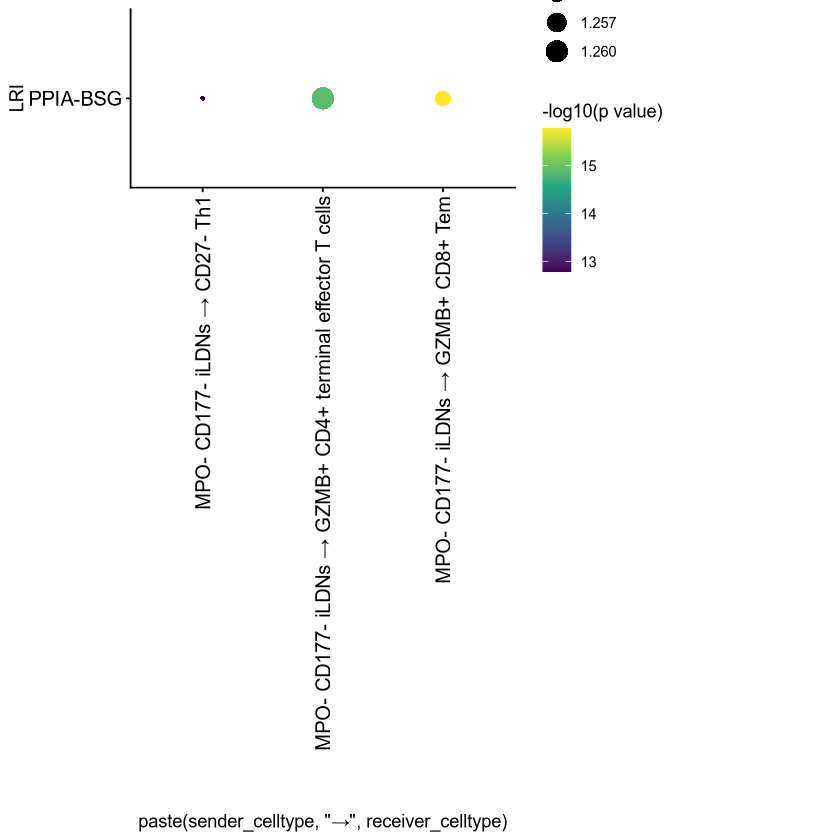

In [104]:
p = ggplot(share, aes(x = paste(sender_celltype, "→", receiver_celltype), y = LRI)) +
  geom_point(aes(size = average_interactions_strength, color = -log10(p.value)),shape=16) +
  scale_color_viridis_c(option = "viridis", name = "-log10(p value)")+
  theme_classic() +
  theme(
    axis.text.y = element_text(size = 12),
    axis.text.x = element_text(size = 12,angle = 90,hjust = 1,vjust = 0.5),
    panel.grid = element_blank()
  )
p

In [108]:
ggsave2(
      paste0("/home/liyanguo/MyImmuCell/12_FastCCC/bubble 90+.pdf"),
      plot = p,
      width = 6,
      height = 6
    )

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'MPO- CD177- iLDNs → CD27- Th1' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'MPO- CD177- iLDNs → GZMB+ CD4+ terminal effector T cells' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'MPO- CD177- iLDNs → GZMB+ CD8+ Tem' in 'mbcsToSbcs': -> substituted for → (U+2192)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'paste(sender_celltype, "→", receiver_celltype)' in 'mbcsToSbcs': -> substituted for → (U+2192)”


# OmniPath 构建receptor(start) → signaling 1 (in_cytoplasm) → signaling 2 (in_cytoplasm) → TF(in_nucleus)

In [3]:
load("../12_FastCCC/omnipath_LRIs_L4.Rdata")

In [14]:
comb_details <- extract_comb(matrix_input, comb_name = '1111111111')
print("交集详细信息：")
print(comb_details)

[1] "交集详细信息："
   [1] "Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS0F739D3DB"                      
   [2] "Adaptive NK cells|Core NDNs|CPI-SS0F739D3DB"                               
   [3] "Adaptive NK cells|CXCL8- PTGS2+ NDNs|CPI-SS0F739D3DB"                      
   [4] "Adaptive NK cells|FOS- NDNs|CPI-SS0F739D3DB"                               
   [5] "Adaptive NK cells|IFIT2- RNF213- NDNs|CPI-SS0F739D3DB"                     
   [6] "Adaptive NK cells|IRF1- GBP2- NDNs|CPI-SS0F739D3DB"                        
   [7] "Adaptive NK cells|MT-ATP6- MT-CO2- NDNs|CPI-SS0F739D3DB"                   
   [8] "Adaptive NK cells|RGS2- NDNs|CPI-SS0F739D3DB"                              
   [9] "Adaptive NK cells|VIM- FLNA- NDNs|CPI-SS0F739D3DB"                         
  [10] "ALPL- MARCKS- NDNs|Adaptive NK cells|CPI-SS085EE60B1"                      
  [11] "ALPL- MARCKS- NDNs|ALPL- MARCKS- NDNs|CPI-SS0315F51DD"                     
  [12] "ALPL- MARCKS- NDNs|ALPL- MARCKS- NDNs|CPI-SS053CE866E"

In [33]:
share = LRIs_links %>% filter(id %in% comb_details) %>%
                        select(-group)  %>%  distinct()  %>% 
                        select(receptor,mediate1,mediate2,end) %>% 
                        mutate(mediator = paste0(mediate1,'+',mediate2))  %>% select(-c(mediate1,mediate2))

In [34]:
edge1 <- share %>%
  count(receptor, mediator, name = "weight") %>%
  mutate(layer = "R-M") %>%
  rename(Source = receptor, Target = mediator)

edge2 <- share %>%
  count(mediator, end, name = "weight") %>%
  mutate(layer = "M-TF") %>%
  rename(Source = mediator, Target = end)

edges <- bind_rows(edge1, edge2) %>% mutate(Type = 'Directed')

In [35]:
edges = edges %>% mutate(Source_type = ifelse(grepl('[+]',Source),'Receptor','mediator'),
                         Target_type = ifelse(grepl('[+]',Target),'mediator','TF'))

In [37]:
edges$weight = round(log2(edges$weight),2)

In [38]:
write.csv(edges,'/home/liyanguo/MyImmuCell/12_FastCCC/share_edges.csv',row.names = F)

In [41]:
# 提取所有唯一节点
nodes_receptor <- edges %>%
  filter(layer == "R-M") %>%
  pull(Source) %>%
  unique() %>%
  tibble(name = ., type = "Receptor")

nodes_mediator <- edges %>%
  filter(layer == "R-M") %>%
  pull(Target) %>%
  unique() %>%
  tibble(name = ., type = "Mediator")

nodes_tf <- edges %>%
  filter(layer == "M-TF") %>%
  pull(Target) %>%
  unique() %>%
  tibble(name = ., type = "TF")

nodes <- bind_rows(nodes_receptor, nodes_mediator, nodes_tf) %>%
  distinct(name, .keep_all = TRUE)

edges <- edges %>%
  select(from = Source, to = Target, weight, layer)

In [44]:
library(igraph)
library(ggraph)
library(scales)

In [45]:
g <- graph_from_data_frame(edges, vertices = nodes, directed = TRUE)

In [52]:
set.seed(0)

layout_radial <- function(graph, type_col) {
  V(graph)$radius <- ifelse(V(graph)$type == "Receptor", 1,
                            ifelse(V(graph)$type == "Mediator", 2, 3))
  
  for (t in c("Receptor", "Mediator", "TF")) {
    idx <- which(V(graph)$type == t)
    n <- length(idx)
    if (n == 0) next
    angles <- seq(0, 2 * pi, length.out = n + 1)[1:n]
    V(graph)[idx]$angle <- angles
  }
  
  x <- V(graph)$radius * cos(V(graph)$angle)
  y <- V(graph)$radius * sin(V(graph)$angle)
  return(cbind(x, y))
}

coords <- layout_radial(g, V(g)$type)

Warning message in geom_node_text(aes(label = name), repel = F, size = 2, show.legend = FALSE, :
“Ignoring unknown parameters: `max.overlaps`”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Receptor–Mediator–TF Network' in 'mbcsToSbcs': - substituted for – (U+2013)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Receptor–Mediator–TF Network' in 'mbcsToSbcs': - substituted for – (U+2013)”


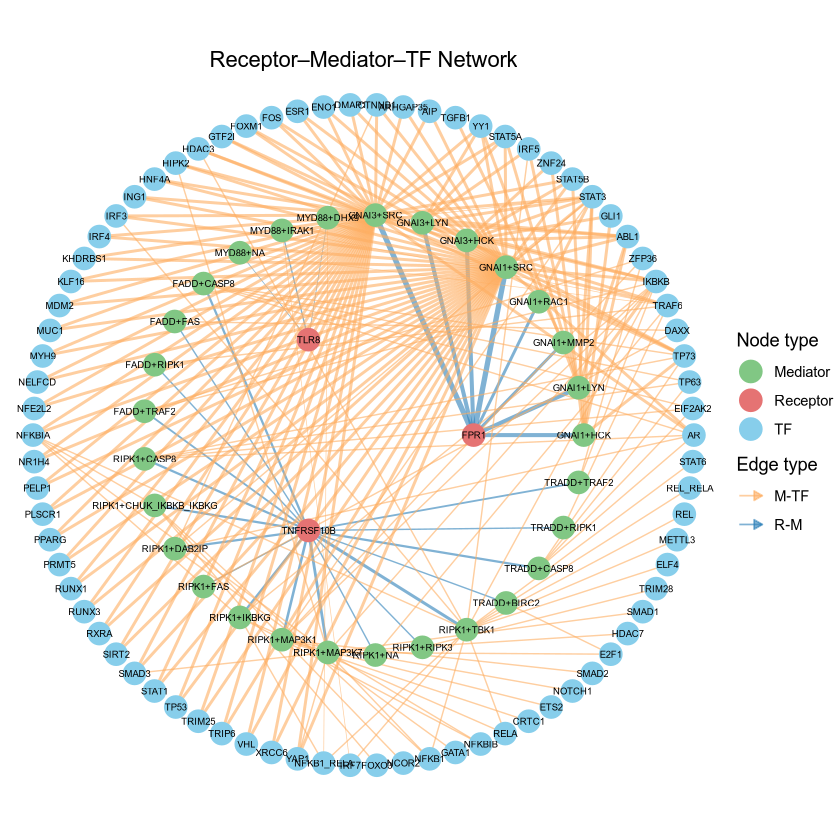

In [79]:
p <- ggraph(g, layout = "manual", x = coords[,1], y = coords[,2]) +

  geom_edge_link(aes(color = layer, width = weight),
                 alpha = 0.6, arrow = arrow(type = "closed", length = unit(2, "mm"))) +

  geom_node_point(aes(color = type), size = 6) +

  geom_node_text(aes(label = name), repel = F, 
                 size = 2, show.legend = FALSE, max.overlaps = Inf) +
  scale_edge_width_continuous(range = c(0.2, 1.5), guide = "none") +
  scale_edge_color_manual(values = c("R-M" = "#2c7fb8", "M-TF" = "#fdae61")) +
  scale_color_manual(values = c("Receptor" = "#E57373", 
                                "Mediator" = "#81C784", 
                                "TF" = "#87CEEB")) +
  theme_void() +
  theme(legend.position = "right",
        plot.title = element_text(hjust = 0.5)) +
  labs(title = "Receptor–Mediator–TF Network",
       color = "Node type", edge_color = "Edge type")+coord_fixed()

print(p)

ggsave("/home/liyanguo/MyImmuCell/12_FastCCC/network_radial.pdf", p, width = 8, height = 6)

In [85]:
enrich = LRIs_links %>% filter(receptor=='FPR1') %>% 
                        select(receptor,mediate1,mediate2,end) %>% distinct()

In [92]:
all_genes <- unique(unlist(enrich[, c("receptor", "mediate1", "mediate2", "end")])) %>% unique()

In [93]:
all_genes# for function enrichment

[1] "FPR1"     "GNAI1"    "GNAI3"    "SRC"      "HCK"      "MMP2"    
 [7] "LYN"      "RAC1"     "IKBKB"    "SMAD3"    "PELP1"    "GLI1"    
[13] "AR"       "STAT3"    "IRF3"     "MDM2"     "TP73"     "RUNX1"   
[19] "STAT5B"   "YAP1"     "TGFB1"    "FOS"      "ING1"     "KLF16"   
[25] "PRMT5"    "HIPK2"    "MYH9"     "HDAC3"    "NR1H4"    "ARHGAP35"
[31] "HNF4A"    "RUNX3"    "TP53"     "TRIP6"    "IRF5"     "NFKBIA"  
[37] "ABL1"     "ENO1"     "PLSCR1"   "VHL"      "CTNNB1"   "RXRA"    
[43] "NELFCD"   "NFE2L2"   "YY1"      "DMAP1"    "KHDRBS1"  "TRIM25"  
[49] "STAT5A"   "MUC1"     "ZNF24"    "SIRT2"    "GTF2I"    "FOXM1"   
[55] "IRF4"     "AIP"      "STAT1"    "PPARG"    "TRAF6"    "XRCC6"   
[61] "ESR1"

# 与表达谱动态关联

In [158]:
merge_data = read.csv('/home/liyanguo/MyImmuCell/12_FastCCC/results_16_CS_L4merge_average_interactions_strength_L4.csv',row.names = 1)

In [163]:
# NDN as sender，看other receiver
data2 = subset(merge_data,grepl('DNs',merge_data$sender_celltype))
intersect(data2$receptor,deg_list$gene)

[1] "TGFBR3"    "CXCR2"     "TNFRSF10C" "CXCR1"     "TYROBP"    "CD244"    
[7] "PECAM1"    "NCR3"

In [164]:
# NDN as receiver，看other sender
data1 = subset(merge_data,grepl('DNs',merge_data$receiver_cell))
intersect(data1$ligand,deg_list$gen)

[1] "ANXA1"   "CXCL8"   "TNFSF10" "CD55"    "LGALS9"  "FCER2"   "CD177"  
[8] "IFNG"

In [161]:
# NDN as receiver，看自身receptor
data1 = subset(merge_data,grepl('DNs',merge_data$receiver_cell))
intersect(data1$receptor,deg_list$gene[grepl('DNs',deg_list$cell_type)])

character(0)

In [162]:
# NDN as sender, 看自身ligand
data2 = subset(merge_data,grepl('DNs',merge_data$sender_celltype))
intersect(data2$ligand,deg_list$gene[grepl('DNs',deg_list$cell_type)])

[1] "CXCL8"   "TNFSF10" "CD177"

# share中举例说明年轻静息，老年升高

In [134]:
merge_data = read.csv('/home/liyanguo/MyImmuCell/12_FastCCC/results_16_CS_L4merge_average_interactions_strength_L4.csv',row.names = 1)

In [135]:
merge_data$id = paste0(merge_data$sender_celltype,'|',merge_data$receiver_celltype,'|',
                       merge_data$LRI_ID_sig)

In [136]:
merge_data_NEU = merge_data[grepl('NDNs',merge_data$id) | grepl('LDNs',merge_data$id),]

In [137]:
comb_details <- extract_comb(matrix_input, comb_name = '1111111111')
print("交集详细信息：")
print(comb_details)

[1] "交集详细信息："
   [1] "Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS0F739D3DB"                      
   [2] "Adaptive NK cells|Core NDNs|CPI-SS0F739D3DB"                               
   [3] "Adaptive NK cells|CXCL8- PTGS2+ NDNs|CPI-SS0F739D3DB"                      
   [4] "Adaptive NK cells|FOS- NDNs|CPI-SS0F739D3DB"                               
   [5] "Adaptive NK cells|IFIT2- RNF213- NDNs|CPI-SS0F739D3DB"                     
   [6] "Adaptive NK cells|IRF1- GBP2- NDNs|CPI-SS0F739D3DB"                        
   [7] "Adaptive NK cells|MT-ATP6- MT-CO2- NDNs|CPI-SS0F739D3DB"                   
   [8] "Adaptive NK cells|RGS2- NDNs|CPI-SS0F739D3DB"                              
   [9] "Adaptive NK cells|VIM- FLNA- NDNs|CPI-SS0F739D3DB"                         
  [10] "ALPL- MARCKS- NDNs|Adaptive NK cells|CPI-SS085EE60B1"                      
  [11] "ALPL- MARCKS- NDNs|ALPL- MARCKS- NDNs|CPI-SS0315F51DD"                     
  [12] "ALPL- MARCKS- NDNs|ALPL- MARCKS- NDNs|CPI-SS053CE866E"

In [217]:
share = merge_data_NEU %>% filter(id %in% comb_details)

In [223]:
plot_data2 = share %>% pivot_wider(id_cols = c(id,ligand,receptor),
              names_from = group,
              values_from = average_interactions_strength,
              values_fill = NA
             ) %>% select('id','ligand','receptor','2-9','10-19','20-29','30-39','40-49','50-59','60-69','70-79','80-89','90+')

In [224]:
plot_data2 = cbind(plot_data2,strsplit2(plot_data2$id,'[|]'))
plot_data2

id,ligand,receptor,2-9,10-19,20-29,30-39,40-49,50-59,60-69,70-79,80-89,90+,1,2,3
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS0F739D3DB,ANXA1,FPR1,2.5360580,2.5516808,2.617674,2.6349653,2.6559736,2.661522,2.710212,2.6965273,2.6847644,2.7043864,Adaptive NK cells,ALPL- MARCKS- NDNs,CPI-SS0F739D3DB
Adaptive NK cells|Core NDNs|CPI-SS0F739D3DB,ANXA1,FPR1,2.5919406,2.5786455,2.643038,2.6672936,2.6857753,2.676658,2.742672,2.7224452,2.7155028,2.7218634,Adaptive NK cells,Core NDNs,CPI-SS0F739D3DB
Adaptive NK cells|CXCL8- PTGS2+ NDNs|CPI-SS0F739D3DB,ANXA1,FPR1,2.6078753,2.5900812,2.638307,2.6537491,2.6788340,2.678274,2.736342,2.7073248,2.7238100,2.7216762,Adaptive NK cells,CXCL8- PTGS2+ NDNs,CPI-SS0F739D3DB
Adaptive NK cells|FOS- NDNs|CPI-SS0F739D3DB,ANXA1,FPR1,2.5823900,2.5869346,2.636878,2.6531124,2.6867968,2.688729,2.749595,2.7249221,2.7210514,2.7251595,Adaptive NK cells,FOS- NDNs,CPI-SS0F739D3DB
Adaptive NK cells|IFIT2- RNF213- NDNs|CPI-SS0F739D3DB,ANXA1,FPR1,2.5344596,2.5217538,2.616364,2.6371884,2.6508191,2.643231,2.715848,2.6946377,2.6843701,2.6943147,Adaptive NK cells,IFIT2- RNF213- NDNs,CPI-SS0F739D3DB
Adaptive NK cells|IRF1- GBP2- NDNs|CPI-SS0F739D3DB,ANXA1,FPR1,2.5552161,2.5472927,2.630304,2.6479463,2.6784987,2.662357,2.736642,2.7165489,2.7081505,2.7220798,Adaptive NK cells,IRF1- GBP2- NDNs,CPI-SS0F739D3DB
Adaptive NK cells|MT-ATP6- MT-CO2- NDNs|CPI-SS0F739D3DB,ANXA1,FPR1,2.5605561,2.5649925,2.625372,2.6494332,2.6741264,2.676006,2.725421,2.7008403,2.6948964,2.7089040,Adaptive NK cells,MT-ATP6- MT-CO2- NDNs,CPI-SS0F739D3DB
Adaptive NK cells|RGS2- NDNs|CPI-SS0F739D3DB,ANXA1,FPR1,2.5480171,2.5395332,2.582818,2.6238938,2.6259377,2.640479,2.694574,2.6652501,2.6679502,2.6804030,Adaptive NK cells,RGS2- NDNs,CPI-SS0F739D3DB
Adaptive NK cells|VIM- FLNA- NDNs|CPI-SS0F739D3DB,ANXA1,FPR1,2.5765151,2.5808262,2.646716,2.6659785,2.6929786,2.686808,2.745829,2.7190980,2.7143992,2.7222300,Adaptive NK cells,VIM- FLNA- NDNs,CPI-SS0F739D3DB


In [225]:
(table(plot_data2$`1`))


                   Adaptive NK cells                   ALPL- MARCKS- NDNs 
                                   9                                   43 
                                ASDC                            Basophils 
                                  19                                   15 
                      CCR4- CD8+ Tcm                       CCR4+ CD8+ Tcm 
                                  18                                   19 
                          CD14+ cDC2                           CD1C+ cDC2 
                                  20                                   13 
                          CD27- MAIT                            CD27- Th1 
                                  19                                   18 
                          CD27- Th17                           CD27+ MAIT 
                                  19                                   18 
                           CD27+ Th1                           CD27+ Th17 
                        

In [226]:
sort(table(plot_data2$`2`))


                                cDC1                                  CLP 
                                   1                                    1 
                          DN T cells                              HSC/MPP 
                                   1                                    1 
                                pDCs                            Platelets 
                                   1                                    1 
             Non-classical monocytes                            Basophils 
                                   4                                    5 
   Proliferative CD8+ memory T cells                           CD1C+ cDC2 
                                   5                                    7 
                          CD14+ cDC2                    Adaptive NK cells 
                                   8                                    9 
                          CD4+ Temra             Core classical monocytes 
                        

In [227]:
table(plot_data2$`3`)


CPI-SC00D92ECAF CPI-SC0542462B9 CPI-SC0DABCC4B5 CPI-SS001865B32 CPI-SS00270ECE6 
              4              18               1              30               9 
CPI-SS01503DD69 CPI-SS016FD0C8A CPI-SS0315F51DD CPI-SS053CE866E CPI-SS061A7E099 
            426               9              72              62              51 
CPI-SS0698C4DC4 CPI-SS07AB1C381 CPI-SS085EE60B1 CPI-SS0AB1A3A6D CPI-SS0BC034428 
             25               9             124              21               9 
CPI-SS0C491A3C1 CPI-SS0CE693E3E CPI-SS0E2453044 CPI-SS0F739D3DB 
              9              11               5             391 

In [228]:
table(plot_data2$ligand)


  ANXA1   CD177    CD44    CD55   CXCL5   CXCL8   FCER2  LGALS9    PPBP    PPIA 
    391      21     426      51      18      97      22      11      18       5 
RNASET2   TGFB1 TNFSF10 
      9     125      92 

In [229]:
table(plot_data2$receptor)


       ADGRE5           BSG         CXCR1         CXCR2          FPR1 
           51             5            43            90           391 
  ITGAX,ITGB2   ITGB2,ITGAM          P4HB        PECAM1 TGFBR1,TGFBR2 
           18             4            11            21             1 
       TGFBR3          TLR8     TNFRSF10B     TNFRSF10C        TYROBP 
          124             9            30            62           426 

In [ ]:
LRIs_links %>% filter(LRI_ID_sig == 'CPI-SS0F739D3DB')

In [ ]:
LRIs_links

## 折线图 可视化不同年龄段的通讯强度

In [144]:
plan(multisession, workers = 64)

In [145]:
id_analysis <- function(target_id, merge_data, p_threshold = 0.05) {
  plot_data <- merge_data %>% filter(id == target_id)
  
  p <- ggplot(plot_data, aes(x = group, y = average_interactions_strength)) +
      geom_line(aes(group = 1),color = "#2E86AB", linewidth = 1) +
      geom_point(size = 3, color = "#A23B72") +
      labs(
        #title = paste0("ID:", target_id),
        x = "Age Group",
        y = "Average Interactions Strength",
        #subtitle = paste0("p-value =", round(p_value, 4))
      ) +
      theme_bw() +
      theme(
        plot.title = element_text(hjust = 0.5),
        legend.position = "none",
        axis.text.x = element_text(angle = 45, hjust = 1)
      )
   ggsave(
      paste0("/home/liyanguo/MyImmuCell/12_FastCCC/pic/",gsub('[|/]',"",target_id), ".png"),
      plot = p,
      width = 8,
      height = 6,
      dpi = 150
    )
  }

In [146]:
unique_ids <- unique(share$id)
result_list <- future_walk(unique_ids, ~id_analysis(.x, share, p_threshold = 0.01))

In [147]:
plan(sequential)

## Bubble plot, 由于不同年龄段有重叠，需要加分组以区分，除非是特异性的

In [178]:
merge_data = read.csv('/home/liyanguo/MyImmuCell/12_FastCCC/results_16_CS_L4merge_average_interactions_strength_L4.csv',row.names = 1)

In [179]:
merge_data$id = paste0(merge_data$sender_celltype,'|',merge_data$receiver_celltype,'|',
                       merge_data$LRI_ID_sig)

In [180]:
merge_data_NEU = merge_data[grepl('NDNs',merge_data$id) | grepl('LDNs',merge_data$id),]

In [181]:
merge_data_NEU <- merge_data_NEU %>%
  mutate(LR = paste(ligand, receptor, sep = "-"))

In [182]:
table(merge_data_NEU$LR)


         ANXA1-FPR1          ANXA1-FPR2           BAG6-NCR3        CD177-PECAM1 
               4079                2071                   3                 227 
        CD44-TYROBP          CD48-CD244         CD55-ADGRE5         CXCL5-CXCR1 
               5035                  37                1306                  90 
        CXCL5-CXCR2         CXCL8-CXCR1         CXCL8-CXCR2   FCER2-ITGAX,ITGB2 
                 90                 657                 720                 216 
  FCER2-ITGB2,ITGAM   ICAM4-ITGB2,ITGAL  IFNG-IFNGR1,IFNGR2         LGALS9-P4HB 
                 48                  21                   2                 242 
         PPBP-CXCR1          PPBP-CXCR2            PPIA-BSG        RNASET2-TLR8 
                 90                  90                 559                 346 
TGFB1-TGFBR1,TGFBR2        TGFB1-TGFBR3   TNFSF10-TNFRSF10B   TNFSF10-TNFRSF10C 
                 86                1551                 369                1128 

In [ ]:
plot_data <- merge_data_NEU %>%
  filter(sender_celltype=="" & ligand=="CD55" & group== '2-9')  %>% mutate(p.value = p.value+1e-30)
plot_data

In [ ]:
plot_data <- merge_data_NEU %>%
  filter(ligand=="PPIA" & group== '90+')  %>% mutate(p.value = p.value+1e-30)
plot_data

In [ ]:
plot_data <- merge_data[grepl('NDNs',merge_data$sender_celltype) & grepl('NDNs',merge_data$receiver_celltype),] %>% 
    mutate(p.value = p.value+1e-30) %>% mutate(LR = paste(ligand, receptor, sep = "-"))
plot_data

In [ ]:
plot_data <- merge_data_NEU %>%
  filter(LR=="TNFSF10-TNFRSF10C" & group== '2-9')  %>% mutate(p.value = p.value+1e-30)  %>% arrange(desc(average_interactions_strength))%>%
  head(20)
plot_data

In [ ]:
plot_data <- merge_data_NEU %>%
  filter(LR=="TNFSF10-TNFRSF10C")  %>% mutate(p.value = p.value+1e-30)  %>% arrange(desc(average_interactions_strength))%>%
  head(20)
plot_data

In [ ]:
plot_data = merge_data_NEU %>%
  filter(id %in% comb_details)

In [189]:
plot_data <- merge_data_NEU %>%
  filter(sender_celltype=="Platelets" & group== '90+')  %>% mutate(p.value = p.value+1e-30)
plot_data

id,sender_celltype,receiver_celltype,LRI_ID_sig,ligand,receptor,p.value,average_interactions_strength,group,LR
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>
Platelets|ALPL- MARCKS- NDNs|CPI-SS00270ECE6,Platelets,ALPL- MARCKS- NDNs,CPI-SS00270ECE6,CXCL5,CXCR2,5.551115e-17,1.851704,90+,CXCL5-CXCR2
Platelets|ALPL- MARCKS- NDNs|CPI-SS07AB1C381,Platelets,ALPL- MARCKS- NDNs,CPI-SS07AB1C381,PPBP,CXCR1,1.665335e-16,2.853167,90+,PPBP-CXCR1
Platelets|ALPL- MARCKS- NDNs|CPI-SS0BC034428,Platelets,ALPL- MARCKS- NDNs,CPI-SS0BC034428,CXCL5,CXCR1,1.665335e-16,1.579452,90+,CXCL5-CXCR1
Platelets|ALPL- MARCKS- NDNs|CPI-SS0C491A3C1,Platelets,ALPL- MARCKS- NDNs,CPI-SS0C491A3C1,PPBP,CXCR2,1.000000e-30,4.228253,90+,PPBP-CXCR2
Platelets|Core NDNs|CPI-SS00270ECE6,Platelets,Core NDNs,CPI-SS00270ECE6,CXCL5,CXCR2,5.551115e-17,1.874960,90+,CXCL5-CXCR2
Platelets|Core NDNs|CPI-SS07AB1C381,Platelets,Core NDNs,CPI-SS07AB1C381,PPBP,CXCR1,5.551115e-17,2.870004,90+,PPBP-CXCR1
Platelets|Core NDNs|CPI-SS0BC034428,Platelets,Core NDNs,CPI-SS0BC034428,CXCL5,CXCR1,5.551115e-17,1.588705,90+,CXCL5-CXCR1
Platelets|Core NDNs|CPI-SS0C491A3C1,Platelets,Core NDNs,CPI-SS0C491A3C1,PPBP,CXCR2,1.000000e-30,4.276590,90+,PPBP-CXCR2
Platelets|CXCL8- PTGS2+ NDNs|CPI-SS00270ECE6,Platelets,CXCL8- PTGS2+ NDNs,CPI-SS00270ECE6,CXCL5,CXCR2,5.551115e-17,1.876781,90+,CXCL5-CXCR2


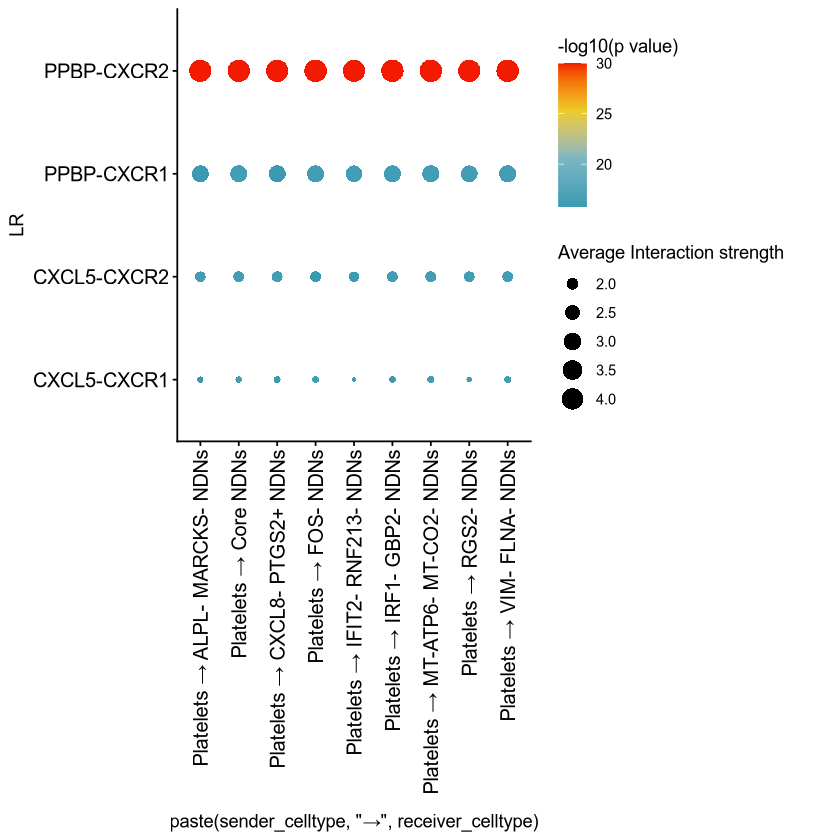

In [190]:
p = ggplot(plot_data, aes(x = paste(sender_celltype, "→", receiver_celltype), y = LR)) +
  geom_point(aes(size = average_interactions_strength, color = -log10(p.value)),shape=16) +
  scale_color_gradientn(colors = c("#3B9AB2","#78B7C5","#EBCC2A","#F21A00")) +
  theme_classic() +
  labs(
    size = "Average Interaction strength",
    color = "-log10(p value)"
  ) +
  theme(
    axis.text.y = element_text(size = 12),
    axis.text.x = element_text(size = 12,angle = 90,hjust = 1,vjust = 0.5),
    panel.grid = element_blank()
  )
p

In [ ]:
ggsave2(
      paste0("/home/liyanguo/MyImmuCell/12_FastCCC/bubble TNFSF10.pdf"),
      plot = p,
      width = 8,
      height = 6
    )

# 怀孕的

# L4

## 获取显著性的受配体对

In [286]:
path = "/home/liyanguo/MyImmuCell/12_FastCCC_P/results_16_CS_L4"

In [287]:
files <- list.files(
  path = path,
  pattern = "_significant_results.tsv",
  recursive = TRUE,
  full.names = TRUE
)

In [288]:
dat <- map_dfr(files, function(i) {
    data <- read.table(i, sep = "\t", header = TRUE, check.names = FALSE)
    data$group <- limma::strsplit2(i, "/")[7]
    return(data)
  })
write.csv(dat,paste0(path,"/significant_results_merge_L4.csv"))

In [289]:
# 筛选分泌型配体 + 生成唯一ID
dat <- dat %>%
    filter(ligand %in% localizations$genesymbol) %>%
    mutate(
      id = paste0(sender_celltype, "|", receiver_celltype, "|", LRI_ID)
    )

## 获取average_interactions_strength.tsv

In [290]:
files <- list.files(
  path = path,
  pattern = "average_interactions_strength.tsv",
  recursive = TRUE,
  full.names = TRUE
)

In [291]:
dat2 <- map_dfr(files, function(i) {
    age_group <- limma::strsplit2(i, "/")[7]
    target_ids <- dat$id[dat$group == age_group]
    
    data <- read.table(i, sep = "\t", header = TRUE, check.names = FALSE)
    colnames(data)[1] <- "celltype"
    
    longer_data <- data %>%
      pivot_longer(
        cols = starts_with("CPI"),
        names_to = "LRI_ID",
        values_to = "average_interactions_strength",
        values_drop_na = TRUE
      ) %>%
      mutate(
        group = age_group,
        id = str_c(celltype, LRI_ID, sep = "|")
      ) %>%
      filter(id %in% target_ids)
    
    return(longer_data)
  })

In [294]:
merge_data <- merge(
    dat, 
    dat2, 
    by = c("id", "group"),  # 同组、同id 匹配
    all.x = TRUE,
    suffixes = c("_sig", "_strength")  # 区分同名列（如LRI_ID）
  ) %>% select(c(id,sender_celltype,receiver_celltype,LRI_ID_sig,ligand,receptor,`p-value`,average_interactions_strength,group))

In [295]:
table(dat$group)


 First trimester Second trimester  Third trimester      Unavailable 
            4508             4272             3732             4844 

In [296]:
table(merge_data$group)


 First trimester Second trimester  Third trimester      Unavailable 
            4508             4272             3732             4844 

In [297]:
merge_data

id,sender_celltype,receiver_celltype,LRI_ID_sig,ligand,receptor,p-value,average_interactions_strength,group
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
Adaptive NK cells|Adaptive NK cells|CPI-SC0DABCC4B5,Adaptive NK cells,Adaptive NK cells,CPI-SC0DABCC4B5,TGFB1,"TGFBR1,TGFBR2",1.665335e-16,1.242722,Unavailable
Adaptive NK cells|Adaptive NK cells|CPI-SS056FF4363,Adaptive NK cells,Adaptive NK cells,CPI-SS056FF4363,CD48,CD244,1.665335e-16,1.114116,Third trimester
Adaptive NK cells|Adaptive NK cells|CPI-SS056FF4363,Adaptive NK cells,Adaptive NK cells,CPI-SS056FF4363,CD48,CD244,0.000000e+00,1.158233,Unavailable
Adaptive NK cells|Adaptive NK cells|CPI-SS085EE60B1,Adaptive NK cells,Adaptive NK cells,CPI-SS085EE60B1,TGFB1,TGFBR3,5.551115e-17,1.388727,First trimester
Adaptive NK cells|Adaptive NK cells|CPI-SS085EE60B1,Adaptive NK cells,Adaptive NK cells,CPI-SS085EE60B1,TGFB1,TGFBR3,5.551115e-17,1.278110,Second trimester
Adaptive NK cells|Adaptive NK cells|CPI-SS085EE60B1,Adaptive NK cells,Adaptive NK cells,CPI-SS085EE60B1,TGFB1,TGFBR3,1.665335e-16,1.254965,Third trimester
Adaptive NK cells|Adaptive NK cells|CPI-SS085EE60B1,Adaptive NK cells,Adaptive NK cells,CPI-SS085EE60B1,TGFB1,TGFBR3,0.000000e+00,1.372975,Unavailable
Adaptive NK cells|Adaptive NK cells|CPI-SS0E2453044,Adaptive NK cells,Adaptive NK cells,CPI-SS0E2453044,PPIA,BSG,5.551115e-17,1.627419,First trimester
Adaptive NK cells|Adaptive NK cells|CPI-SS0E2453044,Adaptive NK cells,Adaptive NK cells,CPI-SS0E2453044,PPIA,BSG,1.665335e-16,1.590573,Second trimester


In [300]:
write.csv(merge_data,paste0(path,"merge_average_interactions_strength_L4.csv"))

# 所有细胞计算NEU参与比例

In [358]:
merge_data = read.csv('/home/liyanguo/MyImmuCell/12_FastCCC_P/results_16_CS_L4merge_average_interactions_strength_L4.csv',row.names = 1)

In [359]:
#去除对比组
merge_data = merge_data %>% filter(group != 'Unavailable')

In [362]:
plot_data2 = merge_data %>% pivot_wider(id_cols = id,
              names_from = group,
              values_from = average_interactions_strength,
              values_fill = NA
             )# %>% select('id') %>% column_to_rownames(var='id')

In [363]:
plot_data2

id,Third trimester,First trimester,Second trimester
<chr>,<dbl>,<dbl>,<dbl>
Adaptive NK cells|Adaptive NK cells|CPI-SS056FF4363,1.1141157,NA,NA
Adaptive NK cells|Adaptive NK cells|CPI-SS085EE60B1,1.2549651,1.388727,1.2781105
Adaptive NK cells|Adaptive NK cells|CPI-SS0E2453044,1.5749543,1.627419,1.5905734
Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS030BB46BB,1.5544865,1.539028,1.5863270
Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS0F739D3DB,2.7937108,2.778042,2.8199470
Adaptive NK cells|Basophils|CPI-SS056FF4363,1.2853359,1.280472,1.3446205
Adaptive NK cells|Basophils|CPI-SS0F6B529A1,3.1004374,3.080809,3.1301966
Adaptive NK cells|CCR4+ CD8+ Tcm|CPI-SS0E2453044,1.4151863,1.429460,1.4228535
Adaptive NK cells|CD14+ cDC2|CPI-SS056FF4363,0.8985576,NA,0.8927424


In [364]:
plot_data2$label = ifelse(grepl('DNs',plot_data2$id), ifelse(grepl('LDNs',plot_data2$id),'LDNs','NDNs'),"Niches")

In [366]:
plot_data = as.data.frame(table(plot_data2$label))
plot_data

Var1,Freq
<fct>,<int>
LDNs,671
NDNs,1454
Niches,2946


In [368]:
label_ = paste0(round(plot_data$Freq/(sum(plot_data$Freq))*100,2),'%')
p=ggplot(plot_data, aes(x = 1, y = Freq, fill = Var1)) +
  geom_col(width = 0.3, color = "white") +                  
  coord_polar(theta = "y", start = 0) +                     
  geom_text(aes(label = label_), 
            position = position_stack(vjust = 0.5), 
            size = 3) +
scale_fill_brewer(palette = "Set3") +
  theme_void() +
  labs(fill = "Cell type") +
  xlim(0.5, 1.5)   # 调整 x 轴范围，产生空心效果

ggsave2("/home/liyanguo/MyImmuCell/12_FastCCC_P/L4_CCC_perrcent_P.pdf",p,width = 5,height = 5)

# 所有细胞分别计算作为信号发送和接受者的总通讯强度

In [369]:
merge_data = read.csv('/home/liyanguo/MyImmuCell/12_FastCCC_P/results_16_CS_L4merge_average_interactions_strength_L4.csv',row.names = 1)

In [370]:
outgoing <- merge_data %>%
  group_by(sender_celltype) %>%
  summarise(outgoing_strength = sum(average_interactions_strength),
           outgoing_num = n())

In [371]:
incoming <- merge_data %>%
  group_by(receiver_celltype) %>%
  summarise(incoming_strength = sum(average_interactions_strength),
           incoming_num = n())

In [372]:
cell_comm <- full_join(outgoing, incoming,
                       by = c("sender_celltype" = "receiver_celltype"))

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_text()`).”


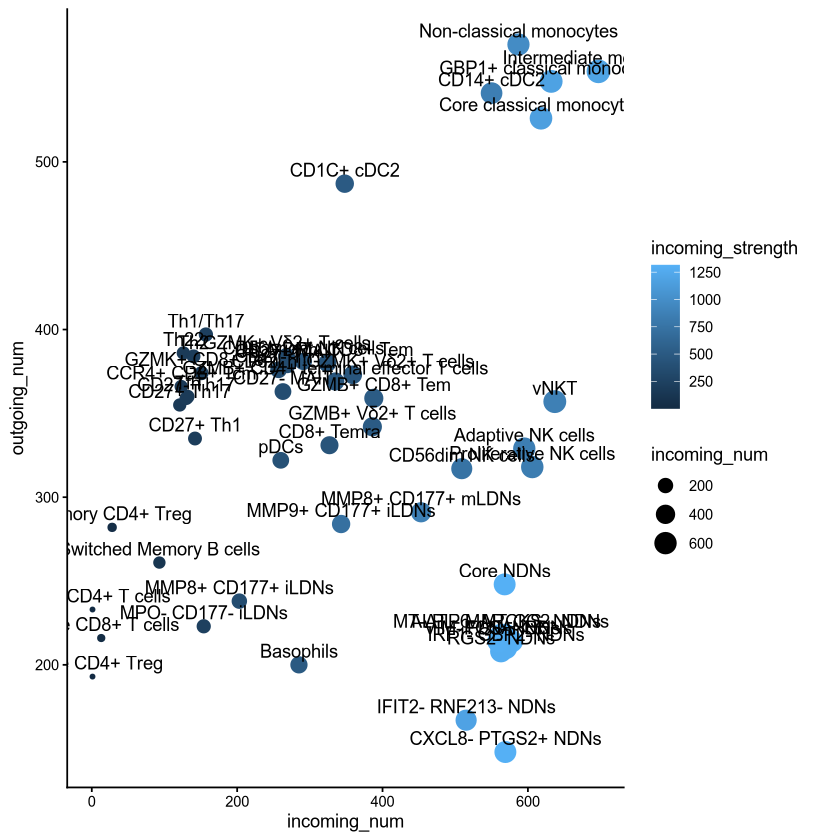

In [373]:
library(ggplot2)
ggplot(cell_comm, aes(x = incoming_num, y = outgoing_num)) +
  geom_point(aes(size=incoming_num,col=incoming_strength)) +
  geom_text(aes(label = sender_celltype), vjust = -0.5) +
  theme_classic()

In [374]:
cell_comm <- cell_comm %>%
    mutate(label = if_else(grepl("DNs", sender_celltype) | grepl("monocyte", sender_celltype) | grepl("Platelets", sender_celltype), sender_celltype, NA))

In [376]:
p = ggplot(cell_comm, aes(x = incoming_num, y = outgoing_num)) +
  geom_point(aes(size = incoming_num, color = incoming_strength), alpha = 0.6,shape=16) +
  geom_text_repel(
    aes(label = label),
    na.rm = TRUE,
    size = 3,
    box.padding = 1,
    point.padding = 0.3,
    segment.color = "grey50",
    segment.size = 0.3,
    max.overlaps = Inf,
      min.segment.length = 1,force_pull = 0.5
  ) +
  scale_size_continuous(range = c(2, 8), name = "Incoming number") +
  scale_color_viridis_c(option = "plasma", name = "Incoming strength") +
  labs(x = "Incoming number", y = "Outgoing number",
       title = "Cell communication strength") +
  theme_classic(base_size = 12) +
  theme(legend.position = "right",
        plot.title = element_text(hjust = 0.5),
        panel.grid.minor = element_blank())
ggsave2("/home/liyanguo/MyImmuCell/12_FastCCC_P/L4_CCC_overview_P.pdf",p,width = 10,height = 8)

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”


# Top受配体可视化

## top LR NEU as sender

In [378]:
merge_data = read.csv('/home/liyanguo/MyImmuCell/12_FastCCC_P/results_16_CS_L4merge_average_interactions_strength_L4.csv',row.names = 1)

In [379]:
merge_data_NEU = merge_data[grepl('NDNs',merge_data$sender_celltype) | grepl('LDNs',merge_data$sender_celltype),]

In [380]:
merge_data_NEU <- merge_data_NEU %>% 
  mutate(LR = paste(ligand, receptor, sep = "_"))

In [381]:
lr_count <- merge_data_NEU %>%
  group_by(group, LR) %>%
  summarise(n = n(), .groups = "drop")

In [382]:
lr_count

group,LR,n
<chr>,<chr>,<int>
First trimester,ANXA1_FPR1,71
First trimester,ANXA1_FPR2,38
First trimester,CD177_PECAM1,66
First trimester,CD44_TYROBP,19
First trimester,CD48_CD244,3
First trimester,CD55_ADGRE5,92
First trimester,CXCL8_CXCR1,60
First trimester,CXCL8_CXCR2,72
First trimester,PPIA_BSG,9


In [383]:
top10 <- lr_count %>%
  group_by(LR) %>%
  summarise(total = sum(n)) %>%
  arrange(desc(total)) %>%
  slice(1:10) %>%
  pull(LR)

In [384]:
top10

[1] "TGFB1_TGFBR3"      "CD55_ADGRE5"       "CXCL8_CXCR2"      
 [4] "CXCL8_CXCR1"       "TNFSF10_TNFRSF10C" "ANXA1_FPR1"       
 [7] "CD177_PECAM1"      "TNFSF10_TNFRSF10B" "ANXA1_FPR2"       
[10] "RNASET2_TLR8"

In [385]:
lr_count <- lr_count %>%
  mutate(LR_group = ifelse(LR %in% top10, LR, "Other"))

In [388]:
plot_df <- lr_count %>%
  group_by(group, LR_group) %>%
  summarise(n = sum(n), .groups = "drop") %>%
  group_by(group) %>%
  mutate(percent = n / sum(n))

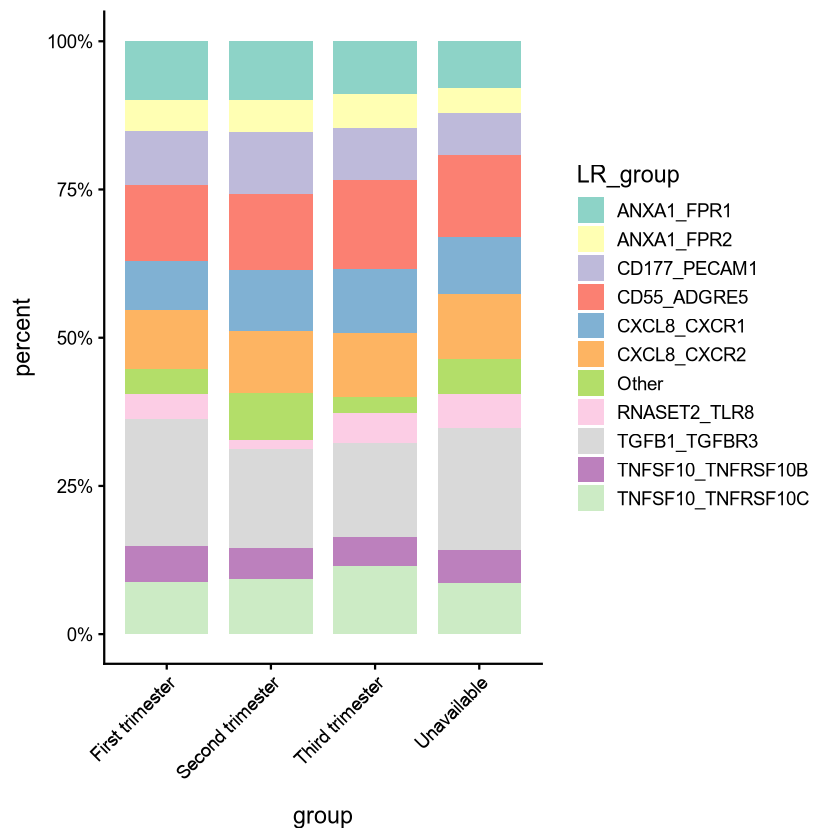

In [389]:
p = ggplot(plot_df, aes(x = group, y = percent, fill = LR_group)) +
  geom_bar(stat = "identity", width = 0.8) +
  scale_y_continuous(labels = scales::percent_format()) +
  scale_fill_brewer(palette = "Set3") +
  theme_classic(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )
p

In [390]:
ggsave2("/home/liyanguo/MyImmuCell/12_FastCCC_P/top10_LR_NEU_as_sender_P.pdf",p,width = 6,height = 4)

## top LR NEU as receiver

In [391]:
merge_data = read.csv('/home/liyanguo/MyImmuCell/12_FastCCC_P/results_16_CS_L4merge_average_interactions_strength_L4.csv',row.names = 1)

In [392]:
merge_data_NEU = merge_data[grepl('NDNs',merge_data$receiver_celltype) | grepl('LDNs',merge_data$receiver_celltype),]

In [393]:
merge_data_NEU <- merge_data_NEU %>% 
  mutate(LR = paste(ligand, receptor, sep = "_"))

In [394]:
lr_count <- merge_data_NEU %>%
  group_by(group, LR) %>%
  summarise(n = n(), .groups = "drop")

In [395]:
top10 <- lr_count %>%
  group_by(LR) %>%
  summarise(total = sum(n)) %>%
  arrange(desc(total)) %>%
  slice(1:10) %>%
  pull(LR)

In [396]:
top10

[1] "ANXA1_FPR1"        "CD44_TYROBP"       "ANXA1_FPR2"       
 [4] "TNFSF10_TNFRSF10C" "PPIA_BSG"          "CD55_ADGRE5"      
 [7] "CXCL8_CXCR2"       "CXCL8_CXCR1"       "CD177_PECAM1"     
[10] "FCER2_ITGAX,ITGB2"

In [398]:
lr_count <- lr_count %>%
  mutate(LR_group = ifelse(LR %in% top10, LR, "Other"))

In [399]:
plot_df <- lr_count %>%
  group_by(group, LR_group) %>%
  summarise(n = sum(n), .groups = "drop") %>%
  group_by(group) %>%
  mutate(percent = n / sum(n))

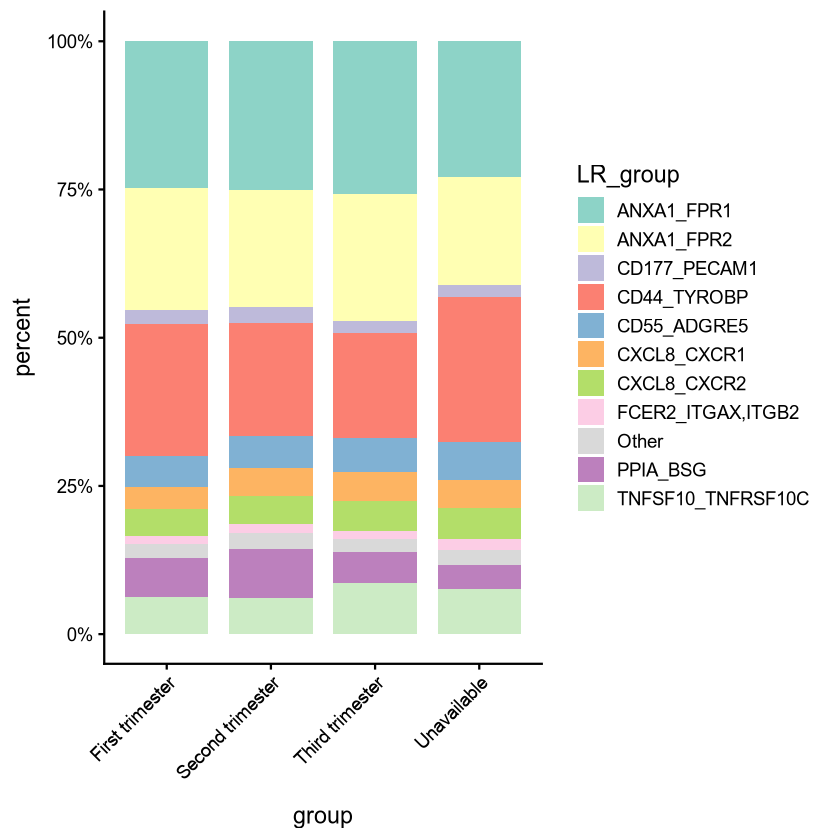

In [400]:
p = ggplot(plot_df, aes(x = group, y = percent, fill = LR_group)) +
  geom_bar(stat = "identity", width = 0.8) +
  scale_y_continuous(labels = scales::percent_format()) +
  scale_fill_brewer(palette = "Set3") +
  theme_classic(base_size = 14) +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1)
  )
p

In [265]:
ggsave2("/home/liyanguo/MyImmuCell/12_FastCCC/top10_LR_NEU receive.pdf",plot = p,width = 6,height = 4)

# 热图可视化与NEU相关，不同年龄段通讯强度和数量

In [1]:
merge_data = read.csv('/home/liyanguo/MyImmuCell/12_FastCCC_P/results_16_CS_L4merge_average_interactions_strength_L4.csv',row.names = 1)

In [2]:
merge_data_NEU = merge_data[grepl('NDNs',merge_data$id) | grepl('LDNs',merge_data$id),]

In [13]:
plot_data1 = merge_data_NEU %>% pivot_wider(id_cols = id,
              names_from = group,
              values_from = average_interactions_strength,
              values_fill = 0
             ) %>% select('id','Unavailable','First trimester','Second trimester','Third trimester') %>% column_to_rownames(var='id')

In [14]:
row_clust <- hclust(dist(plot_data1, method = "euclidean"), method = "ward.D2")

In [15]:
plot_data2 = merge_data_NEU %>% pivot_wider(id_cols = id,
              names_from = group,
              values_from = average_interactions_strength,
              values_fill = NA
             ) %>% select('id','Unavailable','First trimester','Second trimester','Third trimester') %>% column_to_rownames(var='id')

In [16]:
row_scale_with_na <- function(mat) {
  row_na_count <- apply(mat, 1, function(x) sum(!is.na(x)))
  
  row_means <- apply(mat, 1, mean, na.rm = TRUE)
  row_sds <- apply(mat, 1, sd, na.rm = TRUE)
  
  for (i in 1:nrow(mat)) {
    if (row_na_count[i] == 1) {
      row_sds[i] <- 1
      row_means[i] <- 0
    }
  }
  scaled_mat <- t(scale(t(mat), center = row_means, scale = row_sds))
                        
  scaled_mat[is.na(mat)] <- NA
  
  return(scaled_mat)
}

plot_data3 <- row_scale_with_na(plot_data2)

In [21]:
anno = data.frame(row.names = rownames(plot_data3),strsplit2(rownames(plot_data3),'[|]'))[,c(1,2)]
anno$X1 = ifelse(grepl('DNs',anno$X1), ifelse(grepl('LDNs',anno$X1),'LDNs','NDNs'),"Niches")
anno$X2 = ifelse(grepl('DNs',anno$X2), ifelse(grepl('LDNs',anno$X2),'LDNs','NDNs'),"Niches")
anno$X3 = ifelse(rownames(anno) %in% rownames(na.omit(plot_data3)), 'Shared',ifelse(rowSums(is.na(plot_data3), na.rm = TRUE)==3,'Unique','Other'))
colnames(anno) = c('Sender','Receiver','Type')

In [22]:
color_pal <- list(
  heat = colorRampPalette(c("#2166ac", "#4393c3", "white", "#d6604d", "#b2182b"))(100),
  na_col = "#B2BBBE",
  anno_col = list(
    Sender = c(LDNs = "#D0DEAA",NDNs = "#E16C96", Niches = "#0EB0C9"),#
    Receiver = c(LDNs = "#D0DEAA",NDNs = "#E16C96", Niches = "#0EB0C9"),
    Type = c(Shared='#FFD1DC',Unique='#AEC6CF',Other='#FFB347')
  )
)
pheatmap::pheatmap(plot_data3,
                   color = color_pal$heat,
                   na_col = color_pal$na_col,
                   annotation_row = anno,
                   annotation_colors = color_pal$anno_col,
                   cluster_rows=row_clust,cluster_cols =F,
                   show_rownames = F,
                   fontsize = 6,
                   width = 3,height = 6,
         filename = '/home/liyanguo/MyImmuCell/12_FastCCC_P/heatmap_strength_P.pdf')

## 怀孕后丢失和新增的NEU LRIs

In [117]:
merge_data = read.csv('/home/liyanguo/MyImmuCell/12_FastCCC_P/results_16_CS_L4merge_average_interactions_strength_L4.csv',row.names = 1)

In [118]:
merge_data_NEU = merge_data[grepl('NDNs',merge_data$id) | grepl('LDNs',merge_data$id),]

In [119]:
merge_data_NEU

,id,sender_celltype,receiver_celltype,LRI_ID_sig,ligand,receptor,p.value,average_interactions_strength,group
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
12,Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS01503DD69,Adaptive NK cells,ALPL- MARCKS- NDNs,CPI-SS01503DD69,CD44,TYROBP,2.032588e-10,1.813788,Unavailable
13,Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS030BB46BB,Adaptive NK cells,ALPL- MARCKS- NDNs,CPI-SS030BB46BB,ANXA1,FPR2,5.551115e-17,1.539028,First trimester
14,Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS030BB46BB,Adaptive NK cells,ALPL- MARCKS- NDNs,CPI-SS030BB46BB,ANXA1,FPR2,5.551115e-16,1.586327,Second trimester
15,Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS030BB46BB,Adaptive NK cells,ALPL- MARCKS- NDNs,CPI-SS030BB46BB,ANXA1,FPR2,5.551115e-16,1.554486,Third trimester
16,Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS030BB46BB,Adaptive NK cells,ALPL- MARCKS- NDNs,CPI-SS030BB46BB,ANXA1,FPR2,3.330669e-15,1.466119,Unavailable
17,Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS0F739D3DB,Adaptive NK cells,ALPL- MARCKS- NDNs,CPI-SS0F739D3DB,ANXA1,FPR1,0.000000e+00,2.778042,First trimester
18,Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS0F739D3DB,Adaptive NK cells,ALPL- MARCKS- NDNs,CPI-SS0F739D3DB,ANXA1,FPR1,0.000000e+00,2.819947,Second trimester
19,Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS0F739D3DB,Adaptive NK cells,ALPL- MARCKS- NDNs,CPI-SS0F739D3DB,ANXA1,FPR1,0.000000e+00,2.793711,Third trimester
20,Adaptive NK cells|ALPL- MARCKS- NDNs|CPI-SS0F739D3DB,Adaptive NK cells,ALPL- MARCKS- NDNs,CPI-SS0F739D3DB,ANXA1,FPR1,0.000000e+00,2.632836,Unavailable


In [120]:
gene_sets <- with(merge_data_NEU, split(id, paste(group)))

In [121]:
table(merge_data_NEU$group)


 First trimester Second trimester  Third trimester      Unavailable 
            1891             1794             1670             2027 

In [122]:
#独有
pdf(
  file = "/home/liyanguo/MyImmuCell/12_FastCCC_P/Upset_unique_P.pdf",
  width = 4, height = 6
)
color_pal_new <- c('#D2EBC8','#EE934E','#8FA4AE','#8AD9DF')
upset(fromList(gene_sets),nsets = 10,         
      sets.bar.color = color_pal_new,
      main.bar.color = "#617172",
      matrix.color = "#617172",
      nintersects = 10,
      order.by = c('freq',"degree"), decreasing = c(T,F),
      empty.intersections = "on")

dev.off()

agg_record_948568457 
                   2

In [123]:
# 转换为二进制矩阵
matrix_input <- make_comb_mat(gene_sets)

# 查看所有交集
comb_matrix <- comb_size(matrix_input)
print("所有交集大小：")
print(comb_matrix)

[1] "所有交集大小："
1111 1110 1101 1011 0111 1100 1010 1001 0110 0101 0011 1000 0100 0010 0001 
1334   87  147  101   58   56    6  131   20   35   37   29   57   27  184 


In [124]:
names(gene_sets)

[1] "First trimester"  "Second trimester" "Third trimester"  "Unavailable"

In [125]:
plot_data2 = merge_data_NEU %>% pivot_wider(id_cols = id,
              names_from = group,
              values_from = average_interactions_strength,
              values_fill = NA
             ) %>% select('id','Unavailable','First trimester','Second trimester','Third trimester') %>% column_to_rownames(var='id')

In [126]:
## 新增的
plot_data2 = plot_data2 %>% filter(is.na(plot_data2$Unavailable))

In [127]:
comb_details1 = rownames(plot_data2)
length(comb_details1)

[1] 282

In [ ]:
#丢失
comb_details2 <- extract_comb(matrix_input, comb_name = '0001')
print("交集详细信息：")
print(comb_details2)

In [184]:
comb_details_gain = merge_data_NEU[(merge_data_NEU$id %in% comb_details1),]

In [185]:
comb_details_gain = comb_details_gain %>% mutate(Source_type = ifelse(grepl('LDNs',sender_celltype),'LDNs-sender',ifelse(grepl('NDNs',sender_celltype),'NDNs-sender','Niches-sender')),
                         Target_type = ifelse(grepl('LDNs',receiver_celltype),'LDNs-receiver',ifelse(grepl('NDNs',receiver_celltype),'NDNs-receiver','Niches-receiver')))

In [144]:
comb_details_loss = merge_data_NEU[merge_data_NEU$id %in% comb_details2,]

In [146]:
comb_details_loss = comb_details_loss %>% mutate(Source_type = ifelse(grepl('LDNs',sender_celltype),'LDNs-sender',ifelse(grepl('NDNs',sender_celltype),'NDNs-sender','Niches-sender')),
                         Target_type = ifelse(grepl('LDNs',receiver_celltype),'LDNs-receiver',ifelse(grepl('NDNs',receiver_celltype),'NDNs-receiver','Niches-receiver')))

In [147]:
df = rbind(table(comb_details_gain$Source_type,comb_details_gain$Target_type) %>%as.data.frame()  %>% mutate(Type = 'Gain')  %>% rename(sender='Var1',receiver='Var2'),
                  table(comb_details_loss$Source_type,comb_details_loss$Target_type) %>%as.data.frame()  %>% mutate(Type = 'Loss') %>% rename(sender='Var1',receiver='Var2')
                  )

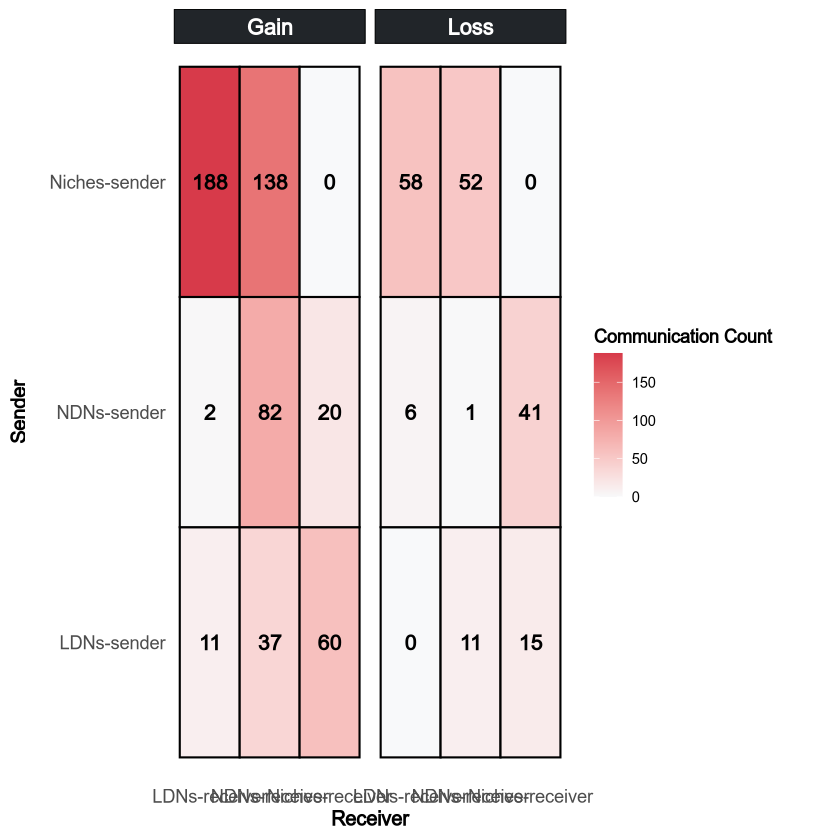

In [148]:
p = ggplot(df, aes(x = receiver, y = sender, fill = Freq)) +
  geom_tile(color = "black", size = 0.6) +
  geom_text(aes(label = Freq), size = 4.5, fontface = "bold") +
  facet_wrap(~Type, ncol = 2) +
  scale_fill_gradient(low = "#F8F9FA", high = "#D73A4A") +
  labs(
    x = "Receiver",
    y = "Sender",
    fill = "Communication Count"
  ) +
  theme_minimal() +
  theme(
    panel.grid = element_blank(),
    strip.text = element_text(size = 13, face = "bold", color = "white"),
    strip.background = element_rect(fill = "#212529"),
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 12, face = "bold"),
    legend.title = element_text(size = 11, face = "bold"),
    legend.position = "right"
  )
p

In [149]:
ggsave("/home/liyanguo/MyImmuCell/12_FastCCC_P/P Loss and Gain.pdf", p, width = 8, height = 4)

In [150]:
table(comb_details_gain$Source_type,comb_details_gain$Target_type)

               
                LDNs-receiver NDNs-receiver Niches-receiver
  LDNs-sender              11            37              60
  NDNs-sender               2            82              20
  Niches-sender           188           138               0

In [151]:
table(comb_details_loss$Source_type,comb_details_loss$Target_type)

               
                LDNs-receiver NDNs-receiver Niches-receiver
  LDNs-sender               0            11              15
  NDNs-sender               6             1              41
  Niches-sender            58            52               0

## Gain的深入研究

In [186]:
comb_details_gain

,id,sender_celltype,receiver_celltype,LRI_ID_sig,ligand,receptor,p.value,average_interactions_strength,group,Source_type,Target_type
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>
196,Adaptive NK cells|IFIT2- RNF213- NDNs|CPI-SS030BB46BB,Adaptive NK cells,IFIT2- RNF213- NDNs,CPI-SS030BB46BB,ANXA1,FPR2,0.000000e+00,1.520305,First trimester,Niches-sender,NDNs-receiver
197,Adaptive NK cells|IFIT2- RNF213- NDNs|CPI-SS030BB46BB,Adaptive NK cells,IFIT2- RNF213- NDNs,CPI-SS030BB46BB,ANXA1,FPR2,4.996004e-16,1.621823,Second trimester,Niches-sender,NDNs-receiver
198,Adaptive NK cells|IFIT2- RNF213- NDNs|CPI-SS030BB46BB,Adaptive NK cells,IFIT2- RNF213- NDNs,CPI-SS030BB46BB,ANXA1,FPR2,1.665335e-16,1.516137,Third trimester,Niches-sender,NDNs-receiver
230,Adaptive NK cells|MMP8+ CD177+ mLDNs|CPI-SS0E2453044,Adaptive NK cells,MMP8+ CD177+ mLDNs,CPI-SS0E2453044,PPIA,BSG,1.221245e-15,1.408116,First trimester,Niches-sender,LDNs-receiver
231,Adaptive NK cells|MMP8+ CD177+ mLDNs|CPI-SS0E2453044,Adaptive NK cells,MMP8+ CD177+ mLDNs,CPI-SS0E2453044,PPIA,BSG,9.436896e-16,1.411798,Second trimester,Niches-sender,LDNs-receiver
232,Adaptive NK cells|MMP8+ CD177+ mLDNs|CPI-SS0E2453044,Adaptive NK cells,MMP8+ CD177+ mLDNs,CPI-SS0E2453044,PPIA,BSG,9.964252e-14,1.369046,Third trimester,Niches-sender,LDNs-receiver
237,Adaptive NK cells|MMP9+ CD177+ iLDNs|CPI-SS0E2453044,Adaptive NK cells,MMP9+ CD177+ iLDNs,CPI-SS0E2453044,PPIA,BSG,7.194245e-14,1.364810,First trimester,Niches-sender,LDNs-receiver
238,Adaptive NK cells|MMP9+ CD177+ iLDNs|CPI-SS0E2453044,Adaptive NK cells,MMP9+ CD177+ iLDNs,CPI-SS0E2453044,PPIA,BSG,1.276756e-15,1.397803,Second trimester,Niches-sender,LDNs-receiver
239,Adaptive NK cells|MMP9+ CD177+ iLDNs|CPI-SS0E2453044,Adaptive NK cells,MMP9+ CD177+ iLDNs,CPI-SS0E2453044,PPIA,BSG,1.665335e-16,1.388267,Third trimester,Niches-sender,LDNs-receiver


In [196]:
comb_details_gain_sub = comb_details_gain %>% filter(grepl('LDN',id)) %>% mutate(LR = paste(ligand, receptor, sep = "-"))

In [189]:
comb_details_gain_sub2 = comb_details_gain %>% filter(grepl('LDN',id)) %>% mutate(LR = paste(ligand, receptor, sep = "-")) %>% filter(ligand == 'PPIA')

In [ ]:
plot_data2 = comb_details_gain_sub %>% pivot_wider(id_cols = id,
              names_from = group,
              values_from = average_interactions_strength,
              values_fill = NA
             )# %>% select('id') %>% column_to_rownames(var='id')

In [ ]:
p = ggplot(comb_details_gain_sub, aes(x = paste(sender_celltype, "→", receiver_celltype), y = LR)) +
  geom_point(aes(size = average_interactions_strength, color = -log10(p.value)),shape=16) +
  scale_color_gradientn(colors = c("#3B9AB2","#78B7C5","#EBCC2A","#F21A00")) +
  theme_classic() +
  labs(
    size = "Average Interaction strength",
    color = "-log10(p value)"
  ) +
  theme(
    axis.text.y = element_text(size = 8),
    axis.text.x = element_text(size = 8,angle = 90,hjust = 1,vjust = 0.5),
    panel.grid = element_blank()
  )
p

In [ ]:
ggsave2(paste0("/home/liyanguo/MyImmuCell/12_FastCCC_P/bubble LDN gain.pdf"),p,width = 12,height = 6)

In [206]:
sankey = comb_details_gain_sub %>% select(sender_celltype,receiver_celltype,LR) %>%  group_by(sender_celltype,receiver_celltype, LR) %>%  summarise(Freq = n(), .groups = "drop")
sankey

sender_celltype,receiver_celltype,LR,Freq
<chr>,<chr>,<chr>,<int>
Adaptive NK cells,MMP8+ CD177+ mLDNs,PPIA-BSG,3
Adaptive NK cells,MMP9+ CD177+ iLDNs,PPIA-BSG,3
Basophils,MMP8+ CD177+ iLDNs,ANXA1-FPR1,2
CCR4+ CD8+ Tcm,MMP8+ CD177+ mLDNs,ANXA1-FPR2,1
CCR4+ CD8+ Tcm,MMP9+ CD177+ iLDNs,PPIA-BSG,1
CD14+ cDC2,MMP8+ CD177+ iLDNs,ANXA1-FPR1,2
CD14+ cDC2,MMP8+ CD177+ iLDNs,PPIA-BSG,2
CD14+ cDC2,MMP8+ CD177+ mLDNs,PPIA-BSG,3
CD1C+ cDC2,MMP8+ CD177+ iLDNs,PPIA-BSG,2


In [214]:
unique(sankey$receiver_celltype[grep('LDN',sankey$receiver_celltype)])

[1] "MMP8+ CD177+ mLDNs" "MMP9+ CD177+ iLDNs" "MMP8+ CD177+ iLDNs"
[4] "MPO- CD177- iLDNs"

In [218]:
df_alluvial

sender_celltype,receiver_celltype,LR,Freq,Sender_plot,Receiver_plot
<chr>,<chr>,<fct>,<int>,<chr>,<chr>
Adaptive NK cells,MMP8+ CD177+ mLDNs,PPIA-BSG,3,Adaptive NK cells_S,MMP8+ CD177+ mLDNs_R
Adaptive NK cells,MMP9+ CD177+ iLDNs,PPIA-BSG,3,Adaptive NK cells_S,MMP9+ CD177+ iLDNs_R
Basophils,MMP8+ CD177+ iLDNs,ANXA1-FPR1,2,Basophils_S,MMP8+ CD177+ iLDNs_R
CCR4+ CD8+ Tcm,MMP8+ CD177+ mLDNs,ANXA1-FPR2,1,CCR4+ CD8+ Tcm_S,MMP8+ CD177+ mLDNs_R
CCR4+ CD8+ Tcm,MMP9+ CD177+ iLDNs,PPIA-BSG,1,CCR4+ CD8+ Tcm_S,MMP9+ CD177+ iLDNs_R
CD14+ cDC2,MMP8+ CD177+ iLDNs,ANXA1-FPR1,2,CD14+ cDC2_S,MMP8+ CD177+ iLDNs_R
CD14+ cDC2,MMP8+ CD177+ iLDNs,PPIA-BSG,2,CD14+ cDC2_S,MMP8+ CD177+ iLDNs_R
CD14+ cDC2,MMP8+ CD177+ mLDNs,PPIA-BSG,3,CD14+ cDC2_S,MMP8+ CD177+ mLDNs_R
CD1C+ cDC2,MMP8+ CD177+ iLDNs,PPIA-BSG,2,CD1C+ cDC2_S,MMP8+ CD177+ iLDNs_R


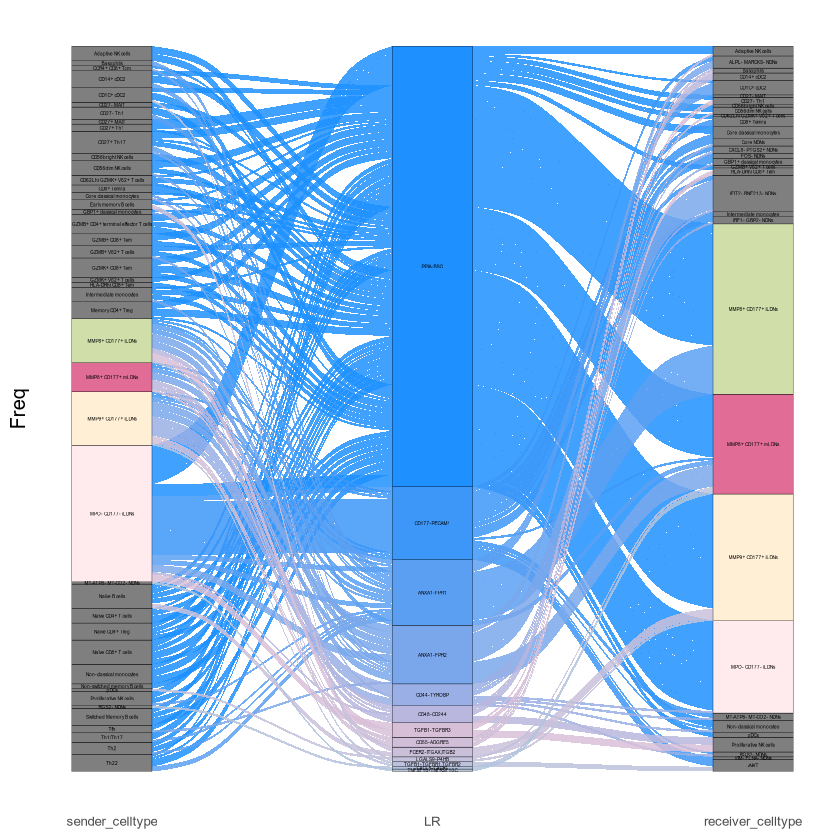

In [225]:
library(tidyverse)
library(ggalluvial)

LR_order <- sankey %>%
  group_by(LR) %>%
  summarise(total = sum(Freq)) %>%
  arrange(desc(total)) %>%
  pull(LR)

df_alluvial <- sankey %>%
  mutate(
    LR = factor(LR, levels = LR_order),
    Sender_plot = paste0(sender_celltype, "_S"),
    Receiver_plot = paste0(receiver_celltype, "_R")
  )

sender_cols <- c("MMP8+ CD177+ iLDNs_S" = "#D0DEAA", "MMP8+ CD177+ mLDNs_S" = "#E16C96",'MMP9+ CD177+ iLDNs_S'='#FFEFD5','MPO- CD177- iLDNs_S'='#FFEBEE')
receiver_cols <- c("MMP8+ CD177+ iLDNs_R" = "#D0DEAA", "MMP8+ CD177+ mLDNs_R" = "#E16C96",'MMP9+ CD177+ iLDNs_R'='#FFEFD5','MPO- CD177- iLDNs_R'='#FFEBEE')

LR_cols <- setNames(
  colorRampPalette(c("#1E90FF", "#D8BFD8", "#B0C4DE"))(length(LR_order)),
  LR_order
)

all_cols <- c(LR_cols, sender_cols, receiver_cols)

p = ggplot(df_alluvial,
       aes(axis1 = Sender_plot, axis2 = LR, axis3 = Receiver_plot,
           y = Freq)) +
  
  geom_alluvium(aes(fill = LR),
                width = 0.25,
                alpha = 0.85) +
  
  geom_stratum(aes(fill = after_stat(stratum)),
               width = 0.25,size = 0.1,
               color = "black") +
  
  geom_text(stat = "stratum",
            aes(label = gsub("_S|_R", "", after_stat(stratum))),
            size = 1) +
  
  scale_fill_manual(values = all_cols) +
  
  scale_x_discrete(limits = c("sender_celltype", "LR", "receiver_celltype"),
                   labels = c("sender_celltype", "LR", "receiver_celltype"),
                   expand = c(.08, .08)) +
  
  theme_minimal(base_size = 12) +
  theme(
    axis.title.x = element_blank(),
    axis.text.y = element_blank(),
    panel.grid = element_blank(),
    axis.text.x = element_text(size = 8),
    legend.position = "none"
  )
p

In [226]:
ggsave2("/home/liyanguo/MyImmuCell/12_FastCCC_P/LDN_sankey.pdf",plot = p,width = 6,height = 10)

Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GZMK+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GZMB+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD62Lhi GZMK+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'GZMB+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'CD62Lhi GZMK+ Vδ2+ T cells' in 'mbcsToSbcs': for δ (U+03B4)”
